In [ ]:
#!pip install xvec
# using xvec https://xvec.readthedocs.io/en/stable/zonal_stats.html
#!pip install easysnowdata --upgrade

In [ ]:
!pip install cartopy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import dask.dataframe as dd
import seaborn as sns
import xarray as xr
import geopandas as gpd
import xvec
import coiled
import dask
from global_snowmelt_runoff_onset.config import Config
import global_snowmelt_runoff_onset.analysis as analysis
from xarray.groupers import BinGrouper
import ee
import flox.xarray
import easysnowdata
import os
import glob
from shapely.geometry import Point
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.colors as colors
import textwrap
import rioxarray
from cartopy import crs as ccrs
from cartopy import feature as cfeature
import easysnowdata
#ee.Initialize()

In [2]:
config = Config('../config/global_config_v5.txt')

Configuration loaded:
resolution = 0.00072000072000072
bands = vv
spatial_chunk_dim = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
valid_tiles_geojson_path = processing/tile_data/valid_tiles.geojson
tile_results_path = processing/tile_data/tile_results_v5.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v5.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_mask_v2/global_modis_snow_mask.zarr


In [3]:
# url = (f"https://data.earthenv.org/mountains/standard/GMBA_Inventory_v2.0_standard_300.zip")
# gmba_gdf = gpd.read_file("zip+" + url)
#gmba_gdf
#gmba_gdf.filter(['MapName','geometry']).explore(column='MapName')
# gmba_gdf.columns
# gmba_gdf.explore(column='Level_03')

In [4]:
# basins_gdf = easysnowdata.hydroclimatology.get_grdc_major_river_basins_of_the_world()
# basins_gdf

In [5]:
# basins_gdf.plot()

In [6]:
# basins_gdf = easysnowdata.hydroclimatology.get_grdc_wmo_basins()
# basins_gdf

In [7]:
# WTU_gdf = gpd.read_file("zip+https://zenodo.org/records/3521933/files/data_ngs_watertowers.zip!/WTU_units/WTU_vector.shp")
# WTU_gdf

In [8]:
#WTU_gdf.explore(column='WTU_NAME')

In [9]:
basin_populations_gdf = gpd.read_file("aggregated_results/river_basins/Hydrobasins_L5_Population_Global.geojson")
basin_populations_gdf

,id,HYBAS_ID,PFAF_ID,total_population,geometry
0,0000000000000000020b,5050558240,56122,9.278136e+03,"POLYGON ((116.24548 -30.69412, 116.24619 -30.6..."
1,0000000000000000020c,5050558410,56123,1.362956e+04,"POLYGON ((116.41668 -32.31458, 116.42048 -32.3..."
2,0000000000000000020d,5050560670,56125,4.885879e+03,"POLYGON ((117.61224 -31.6428, 117.61724 -31.64..."
3,0000000000000000020e,5050560780,56124,5.921051e+03,"POLYGON ((117.62917 -31.91667, 117.63138 -31.9..."
4,0000000000000000020f,5050546000,56126,7.170845e+02,"POLYGON ((118 -30.52917, 118.00221 -30.52973, ..."
...,...,...,...,...,...
4729,00000000000000001279,4050028560,45377,3.725325e+06,"POLYGON ((79.13333 12.35417, 79.1339 12.34362,..."
4730,0000000000000000127a,4050028680,45379,5.320099e+06,"POLYGON ((78.2625 11.60833, 78.27083 11.60833,..."
4731,0000000000000000127b,4050028770,45390,2.347101e+07,"MULTIPOLYGON (((78.72856 9.15261, 78.73194 9.1..."
4732,0000000000000000127c,4050029530,45401,1.589016e+07,"MULTIPOLYGON (((76.37917 9.62083, 76.37978 9.6..."


In [ ]:
basin_populations_gdf['total_population'].sum()

print('total population in all basins (billion):', basin_populations_gdf['total_population'].sum()/1e9)

In [ ]:
# f,ax=plt.subplots(figsize=(20,10))
# basin_populations_gdf.plot(ax=ax,column='total_population',legend=True, cmap='viridis',norm=colors.LogNorm(vmin=1, vmax=basin_populations_gdf['total_population'].max()))

In [ ]:
#basins_gdf.explore(column='WMOBB_BASIN')

In [10]:
basins_gdf = easysnowdata.hydroclimatology.get_hydroBASINS(level=5)
basins_gdf

Getting geometries for Africa...
Africa takes a bit longer because we have to temporarily save the file due to read issue...
Getting geometries for Arctic...
Getting geometries for Asia...
Getting geometries for Australia...
Getting geometries for Europe...
Getting geometries for Greenland...
Getting geometries for North America...
Getting geometries for South America...
Getting geometries for Siberia...


,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
0,1050000010,0,1050000010,1050000010,0.0,0.0,45567.0,45567.0,11101,0,1,0,1,"MULTIPOLYGON (((35.17778 24.64583, 35.17279 24..."
1,1050001370,0,1050001370,1050001370,0.0,0.0,11678.4,11678.5,11102,0,0,1,2,"POLYGON ((35.14167 22.58333, 35.15316 22.58271..."
2,1050001380,0,1050001380,1050001380,0.0,0.0,5524.6,5524.6,11103,0,1,0,3,"POLYGON ((35.92083 22.50417, 35.91424 22.50452..."
3,1050001510,0,1050001510,1050001510,0.0,0.0,42400.5,42400.5,11104,0,0,1,4,"POLYGON ((35.24167 21.59167, 35.24202 21.60245..."
4,1050001520,0,1050001520,1050001520,0.0,0.0,16198.5,16198.5,11105,0,1,0,5,"MULTIPOLYGON (((36.63194 22.2875, 36.6286 22.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,3050024510,3050481930,3050024510,3050001840,0.0,1848.1,13573.8,13573.8,31260,2,0,3,404,"POLYGON ((62.94167 52.67917, 62.9411 52.68138,..."
404,3050024540,3050001840,3050024540,3050001840,0.0,1.0,22286.5,22286.5,31205,2,0,2,405,"POLYGON ((79.77917 51.97917, 79.77973 51.98138..."
405,3050024640,3050679760,3050024640,3050004740,0.0,4239.9,5144.4,5144.4,32280,2,0,3,406,"POLYGON ((105.275 46.975, 105.28554 46.97557, ..."
406,3050024960,3050001840,3050024960,3050001840,0.0,1.0,19166.9,19166.9,31203,2,0,2,407,"POLYGON ((78.225 52.325, 78.22742 52.32535, 78..."


In [11]:
# add 'POPULATION' column to basins_gdf
basins_gdf = basins_gdf.merge(basin_populations_gdf[['HYBAS_ID','total_population']], on='HYBAS_ID', how='left')
basins_gdf = basins_gdf.rename(columns={'total_population': 'POPULATION'})
basins_gdf

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry,POPULATION
0,1050000010,0,1050000010,1050000010,0.0,0.0,45567.0,45567.0,11101,0,1,0,1,"MULTIPOLYGON (((35.17778 24.64583, 35.17279 24...",454453.709453
1,1050001370,0,1050001370,1050001370,0.0,0.0,11678.4,11678.5,11102,0,0,1,2,"POLYGON ((35.14167 22.58333, 35.15316 22.58271...",7931.771638
2,1050001380,0,1050001380,1050001380,0.0,0.0,5524.6,5524.6,11103,0,1,0,3,"POLYGON ((35.92083 22.50417, 35.91424 22.50452...",6593.424997
3,1050001510,0,1050001510,1050001510,0.0,0.0,42400.5,42400.5,11104,0,0,1,4,"POLYGON ((35.24167 21.59167, 35.24202 21.60245...",117412.544791
4,1050001520,0,1050001520,1050001520,0.0,0.0,16198.5,16198.5,11105,0,1,0,5,"MULTIPOLYGON (((36.63194 22.2875, 36.6286 22.2...",42922.135617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4729,3050024510,3050481930,3050024510,3050001840,0.0,1848.1,13573.8,13573.8,31260,2,0,3,404,"POLYGON ((62.94167 52.67917, 62.9411 52.68138,...",51916.220892
4730,3050024540,3050001840,3050024540,3050001840,0.0,1.0,22286.5,22286.5,31205,2,0,2,405,"POLYGON ((79.77917 51.97917, 79.77973 51.98138...",104481.186272
4731,3050024640,3050679760,3050024640,3050004740,0.0,4239.9,5144.4,5144.4,32280,2,0,3,406,"POLYGON ((105.275 46.975, 105.28554 46.97557, ...",3848.093983
4732,3050024960,3050001840,3050024960,3050001840,0.0,1.0,19166.9,19166.9,31203,2,0,2,407,"POLYGON ((78.225 52.325, 78.22742 52.32535, 78...",306683.596285


In [ ]:
# cluster = coiled.Cluster(idle_timeout="10 minutes",
#                         n_workers=50, #10
#                         worker_memory="32 GB", #32 # 128 and 32 almost worked
#                         worker_cpu=4, # 4,
#                         scheduler_memory="128 GB",
#                         spot_policy="spot",
#                         environ={"GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR"},
#                         workspace="uwtacolab",
#                         )

# client = cluster.get_client()

In [ ]:
# import dask.delayed

# #@dask.delayed
# def process_and_save_river_basin(river_basin_id, parquet_path, filesystem, 
#                                   dem_bin_low=0, dem_bin_high=9000, 
#                                   dem_bin_interval=100, aspect_bin_interval=15):
#     """Process single mountain range and save to netCDF"""
#     #print(f'Processing mountain range {mountain_range_id}...')
    
#     # Setup bins and coordinates
#     dem_bins = np.arange(dem_bin_low, dem_bin_high+dem_bin_interval, dem_bin_interval)
#     aspect_bins = np.arange(0, 360+aspect_bin_interval, aspect_bin_interval)
#     water_years = range(2015, 2025)
#     dem_coords = dem_bins[:-1] + dem_bin_interval/2
#     aspect_coords = aspect_bins[:-1] + aspect_bin_interval/2
#     stat_coords = ["mean", "median", "count"]

#     # Read data
#     cols_needed = ['PFAF_ID', 'dem', 'aspect', 'runoff_onset_median', 'runoff_onset_mad'] + \
#                   [f'runoff_onset_WY{year}' for year in water_years]
    
#     range_ddf = dd.read_parquet(
#         parquet_path,
#         filesystem=filesystem,
#         columns=cols_needed,
#         #storage_options={"anon":       
#         filters=[('PFAF_ID', '==', river_basin_id)]
#     ).repartition(partition_size="100MB").persist()

#     # Create bins and calculate anomalies
#     def bin_and_anomaly(df):
#         df = df.dropna(subset=['dem', 'aspect'])
#         df['dem_bin'] = pd.cut(df['dem'], dem_bins).apply(lambda x: x.left+(dem_bin_interval/2) if pd.notnull(x) else np.nan)
#         df['aspect_bin'] = pd.cut(df['aspect'], aspect_bins).apply(lambda x: x.left+(aspect_bin_interval/2) if pd.notnull(x) else np.nan)
#         df['dem_bin'] = df['dem_bin'].astype('Int64')
#         df['aspect_bin'] = df['aspect_bin'].astype('Float64')
        
#         # Calculate anomalies
#         for year in water_years:
#             col = f'runoff_onset_WY{year}'
#             anom_col = f'runoff_onset_anomaly_WY{year}'
#             df[anom_col] = df[col].where(df[col] > 0) - df['runoff_onset_median']
        
#         return df

#     range_ddf = range_ddf.map_partitions(bin_and_anomaly)
#     range_ddf = range_ddf.dropna(subset=['dem_bin', 'aspect_bin'])
#     range_ddf = range_ddf.persist()

#     # Calculate static statistics
#     #print("Computing static aggregations...")
#     agg_static = range_ddf.groupby(['dem_bin', 'aspect_bin']).agg({
#         'runoff_onset_median': ['mean', 'median', 'count'],
#         'runoff_onset_mad': ['mean', 'median', 'count']
#     }).compute()

#     #print("Computing yearly aggregations...")
#     yearly_aggs = []
#     anomaly_aggs = []
    
#     for year in water_years:
#         year_col = f'runoff_onset_WY{year}'
#         # Filter out -9999 values
#         year_data = range_ddf[range_ddf[year_col] > 0][['dem_bin', 'aspect_bin', year_col]]
        
#         year_agg = year_data.groupby(['dem_bin', 'aspect_bin']).agg({
#             year_col: ['mean', 'median', 'count']
#         }).compute()
        
#         year_agg.columns = ['mean', 'median', 'count']
#         year_agg = year_agg.reset_index()
#         year_agg['water_year'] = year
#         yearly_aggs.append(year_agg)

#         # Process anomaly data that was calculated earlier
#         anom_col = f'runoff_onset_anomaly_WY{year}'
#         anom_data = range_ddf.dropna(subset=[anom_col])[['dem_bin', 'aspect_bin', anom_col]]
        
#         anom_agg = anom_data.groupby(['dem_bin', 'aspect_bin']).agg({
#             anom_col: ['mean', 'median', 'count']
#         }).compute()
        
#         anom_agg.columns = ['mean', 'median', 'count']
#         anom_agg = anom_agg.reset_index()
#         anom_agg['water_year'] = year
#         anomaly_aggs.append(anom_agg)

#     # Convert to pandas DataFrames
#     yearly_aggs = pd.concat(yearly_aggs, ignore_index=True)
#     anomaly_aggs = pd.concat(anomaly_aggs, ignore_index=True)

    
#     # Create dataset
#     ds = xr.Dataset(
#         coords={
#             'elevation': dem_coords,
#             'aspect': aspect_coords,
#             'statistic': stat_coords,
#             'water_year': list(water_years)
#         }
#     )

#     # Initialize arrays
#     shape_static = (len(ds.elevation), len(ds.aspect), len(ds.statistic))
#     shape_yearly = shape_static + (len(ds.water_year),)

#     ds['runoff_onset_median'] = xr.DataArray(np.full(shape_static, np.nan), 
#         dims=('elevation', 'aspect', 'statistic'))
#     ds['runoff_onset_mad'] = xr.DataArray(np.full(shape_static, np.nan), 
#         dims=('elevation', 'aspect', 'statistic'))
#     ds['runoff_onset'] = xr.DataArray(np.full(shape_yearly, np.nan), 
#         dims=('elevation', 'aspect', 'statistic', 'water_year'))
#     ds['runoff_onset_anomaly'] = xr.DataArray(np.full(shape_yearly, np.nan), 
#         dims=('elevation', 'aspect', 'statistic', 'water_year'))

#     # Fill values using pandas indexing
#     for dem in ds.elevation.values:
#         for asp in ds.aspect.values:
#             # Fill static variables
#             static_mask = (agg_static.index.get_level_values('dem_bin') == dem) & \
#                          (agg_static.index.get_level_values('aspect_bin') == asp)
            
#             if static_mask.any():
#                 static_data = agg_static[static_mask]
#                 for stat in ['mean', 'median', 'count']:
#                     ds['runoff_onset_median'].loc[{
#                         'elevation': dem,
#                         'aspect': asp,
#                         'statistic': stat
#                     }] = static_data[('runoff_onset_median', stat)].iloc[0]
                    
#                     ds['runoff_onset_mad'].loc[{
#                         'elevation': dem,
#                         'aspect': asp,
#                         'statistic': stat
#                     }] = static_data[('runoff_onset_mad', stat)].iloc[0]
            
#             # Fill yearly variables
#             year_mask = (yearly_aggs['dem_bin'] == dem) & (yearly_aggs['aspect_bin'] == asp)
#             anom_mask = (anomaly_aggs['dem_bin'] == dem) & (anomaly_aggs['aspect_bin'] == asp)
            
#             for stat in ['mean', 'median', 'count']:
#                 year_data = yearly_aggs[year_mask]
#                 if not year_data.empty:
#                     for _, row in year_data.iterrows():
#                         ds['runoff_onset'].loc[{
#                             'elevation': dem,
#                             'aspect': asp,
#                             'statistic': stat,
#                             'water_year': row['water_year']
#                         }] = row[stat]
                
#                 anom_data = anomaly_aggs[anom_mask]
#                 if not anom_data.empty:
#                     for _, row in anom_data.iterrows():
#                         ds['runoff_onset_anomaly'].loc[{
#                             'elevation': dem,
#                             'aspect': asp,
#                             'statistic': stat,
#                             'water_year': row['water_year']
#                         }] = row[stat]

#     # Add attributes
#     ds.elevation.attrs['units'] = 'meters'
#     ds.aspect.attrs['units'] = 'degrees'
#     ds.runoff_onset.attrs['units'] = 'day of water year'
#     ds.runoff_onset_anomaly.attrs['units'] = 'days'
#     ds.runoff_onset_median.attrs['units'] = 'day of water year'
#     ds.runoff_onset_mad.attrs['units'] = 'days'
    
#     ds.attrs['location'] = river_basin_id

#     return ds.compute()

# @dask.delayed
# def get_river_basins(parquet_path, filesystem):
#     mountain_ranges = dd.read_parquet(parquet_path, 
#                                     filesystem=filesystem,
#                                     columns=['PFAF_ID'],
#                                     )['PFAF_ID'].unique().compute()
#     return mountain_ranges
    
# def process_all_river_basins(parquet_path, output_dir, filesystem, batch_size=30):
#     """Process mountain ranges in batches"""

#     os.makedirs(output_dir, exist_ok=True)

#     # Get all mountain ranges once
#     river_basins = get_river_basins(parquet_path, filesystem).compute()
    
#     # Filter out already processed ranges
#     unprocessed_basins = [
#         rb_id for rb_id in river_basins 
#         if not os.path.exists(f"{output_dir}/river_basin_{rb_id}.nc")
#     ]

#     # Process in batches
#     for i in range(0, len(unprocessed_basins), batch_size):
#         batch = unprocessed_basins[i:i + batch_size]
#         futures = []

#         print(f"Processing batch {i//batch_size + 1} of {(len(unprocessed_basins)-1)//batch_size + 1}")
        
#         # Submit batch of tasks
#         for rb_id in batch:
#             future = client.submit(process_and_save_river_basin, rb_id, parquet_path, filesystem)
#             futures.append(future)

#         # Wait for batch completion and save results
#         for future, result in dask.distributed.as_completed(futures, with_results=True):
#             rb_id = result.attrs['location']
#             output_file = f"{output_dir}/river_basin_{rb_id}.nc"
#             result.to_netcdf(output_file)
#             print(f"Saved to {output_file}")

#         # Optional: restart client between batches to clear memory
#         client.restart()

In [ ]:
# client.restart()
# process_all_river_basins(parquet_path="snowmelt/analysis/full_datasets/v5_basins/fcf_lte_50",
#                             output_dir ="aggregated_results/river_basins/v5_basins/fcf_lte_50",
#                             filesystem=config.azure_blob_fs)
# client.restart()

In [41]:
def merge_river_basin_netcdfs(netcdf_dir):

    """Merge all river basin netCDFs"""
    nc_files = sorted(glob.glob(f"{netcdf_dir}/river_basin_4*.nc"))
    datasets = []
    
    for nc_file in nc_files:
        ds = xr.open_dataset(nc_file,decode_times=False)
        rb_id = int(nc_file.split('_')[-1].split('.')[0])
        ds = ds.expand_dims({'river_basin': [rb_id]})
        datasets.append(ds)
    
    merged_ds = xr.concat(datasets, dim='river_basin')


    merged_ds['aspect'] = np.deg2rad(merged_ds['aspect'])
    merged_ds['aspect'].attrs['units'] = 'radians'

    merged_ds = merged_ds.sel(river_basin=merged_ds.river_basin != -9999)


    merged_ds = merged_ds.sortby('river_basin')

    merged_ds['runoff_onset_elev_relative'] = merged_ds['runoff_onset_median'] - merged_ds['runoff_onset_median'].median(dim='aspect')
    merged_ds['runoff_onset_elev_relative'].loc[{'statistic': 'count'}] = merged_ds['runoff_onset_median'].sel(statistic='count')
    
    return merged_ds

In [42]:
netcdf_dir = "aggregated_results/river_basins/v5_basins/fcf_lte_50"
merged_ds = merge_river_basin_netcdfs(netcdf_dir)
merged_ds

<xarray.Dataset> Size: 383MB
Dimensions:                     (river_basin: 321, elevation: 90, aspect: 24,
                                 statistic: 3, water_year: 10)
Coordinates:
  * river_basin                 (river_basin) int64 3kB 41100 41200 ... 49207
  * elevation                   (elevation) float64 720B 50.0 150.0 ... 8.95e+03
  * aspect                      (aspect) float64 192B 0.1309 0.3927 ... 6.152
  * statistic                   (statistic) <U6 72B 'mean' 'median' 'count'
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset_median         (river_basin, elevation, aspect, statistic) float64 17MB ...
    runoff_onset_mad            (river_basin, elevation, aspect, statistic) float64 17MB ...
    runoff_onset                (river_basin, elevation, aspect, statistic, water_year) float64 166MB ...
    runoff_onset_anomaly        (river_basin, elevation, aspect, statistic, water_year) float64 166MB ...
    runoff_onset_elev_relative  (river_basin, elevation, aspect, statistic) float64 17MB ...
Attributes:
    location:  41100

In [43]:
# create weighted average of variables in each basin, weighted by count of samples in each bin. should create a basin_mean and basin_count variable
total_count_ds = merged_ds.sel(statistic='count').sum(dim=['elevation','aspect'])

basin_mean_ds = (merged_ds.sel(statistic='count')*merged_ds.sel(statistic='mean')).sum(dim=['elevation','aspect'])/(total_count_ds)

weighted_mean_ds = xr.concat([basin_mean_ds, total_count_ds], 
                           dim=pd.Index(['basin_mean', 'basin_count'], name='statistic'))

weighted_mean_ds

<xarray.Dataset> Size: 121kB
Dimensions:                     (statistic: 2, river_basin: 321, water_year: 10)
Coordinates:
  * river_basin                 (river_basin) int64 3kB 41100 41200 ... 49207
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
  * statistic                   (statistic) object 16B 'basin_mean' 'basin_co...
Data variables:
    runoff_onset_median         (statistic, river_basin) float64 5kB 193.4 .....
    runoff_onset_mad            (statistic, river_basin) float64 5kB 10.05 .....
    runoff_onset                (statistic, river_basin, water_year) float64 51kB ...
    runoff_onset_anomaly        (statistic, river_basin, water_year) float64 51kB ...
    runoff_onset_elev_relative  (statistic, river_basin) float64 5kB -1.43 .....
Attributes:
    location:  41100

In [44]:
# first remove all basins from basins_gdf with no data in merged_ds
basins_filtered_gdf = basins_gdf[basins_gdf['PFAF_ID'].isin(merged_ds.river_basin.values)]

column_dict = {
    'HYBAS_ID': 'first',
    'NEXT_DOWN': 'first',
    'NEXT_SINK': 'first',
    'MAIN_BAS': 'first',
    'DIST_SINK': 'first',
    'DIST_MAIN': 'first',
    'SUB_AREA': np.sum,
    'UP_AREA': 'first',
    'PFAF_ID': 'first',
    'ENDO': 'first',
    'COAST': 'first',
    'ORDER': 'first',
    'SORT': 'first',
    'POPULATION': np.sum,
}

basins_filtered_gdf = basins_filtered_gdf.dissolve(by='PFAF_ID', aggfunc=column_dict).drop(columns=['PFAF_ID']).reset_index()


#basins_filtered_gdf = basins_filtered_gdf[basins_filtered_gdf['PFAF_ID']!=35301] # issue with basin crossing -180/180, causes duplicate basins_gdf[basins_gdf['PFAF_ID'] == 35301].plot()
#weighted_mean_filtered_ds = weighted_mean_ds.where(weighted_mean_ds.river_basin != 35301, drop=True)
weighted_mean_filtered_ds = weighted_mean_ds

basins_filtered_gdf

/home/eric/miniconda3/envs/new_global_snowmelt_runoff_onset/lib/python3.13/site-packages/geopandas/geodataframe.py:2274: FutureWarning: The provided callable <function sum at 0x7fda146b4680> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  aggregated_data = data.groupby(**groupby_kwargs).agg(aggfunc, **kwargs)


,PFAF_ID,geometry,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,ENDO,COAST,ORDER,SORT,POPULATION
0,41100,"MULTIPOLYGON (((141.21316 46.23725, 141.21184 ...",4050034510,0,4050034510,4050034510,0.0,0.0,74997.4,74997.4,0,1,0,473,4.252397e+05
1,41200,"MULTIPOLYGON (((138.99953 41.00164, 139.00267 ...",4050037060,0,4050037060,4050037060,0.0,0.0,85506.2,85506.2,0,1,0,474,5.276289e+06
2,41301,"MULTIPOLYGON (((132.02836 33.74232, 132.03297 ...",4050041320,0,4050041320,4050041320,0.0,0.0,231936.1,231936.1,0,1,0,478,1.049965e+08
3,41305,"MULTIPOLYGON (((129.74167 32.63333, 129.74075 ...",4050039450,0,4050039450,4050039450,0.0,0.0,39397.8,39397.8,0,1,0,475,1.252561e+07
4,42100,"MULTIPOLYGON (((137.06022 54.60882, 137.06454 ...",4050034410,0,4050034410,4050034410,0.0,0.0,2359.3,2359.3,0,1,0,472,4.839323e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,49203,"POLYGON ((85.79167 35.13333, 85.7938 35.13269,...",4050050980,0,4050050980,4050050980,0.0,0.0,44799.5,44799.5,2,0,1,656,0.000000e+00
317,49204,"POLYGON ((86.60833 35.50417, 86.60833 35.52083...",4050051740,0,4050051740,4050051740,0.0,0.0,35342.8,35342.8,2,0,1,682,0.000000e+00
318,49205,"POLYGON ((85.94583 36.2375, 85.94367 36.23812,...",4050052120,0,4050052120,4050052120,0.0,0.0,28429.3,28429.3,2,0,1,693,0.000000e+00
319,49206,"POLYGON ((89.5125 34.07083, 89.51215 34.06841,...",4050051160,0,4050051160,4050051160,0.0,0.0,24221.0,24221.0,2,0,1,664,0.000000e+00


In [45]:
# create a new geodataframe with the weighted mean runoff onset date, mad, pfaf id, and geometry. we should assign in some sort of join or merge with the pfaf id to make sure we are referring to the same basins
basins_means_gdf = basins_filtered_gdf[['PFAF_ID', 'SUB_AREA','POPULATION','geometry']].copy()
basins_means_gdf = basins_means_gdf.sort_values(by='PFAF_ID')
basins_means_gdf['runoff_onset_median'] = weighted_mean_filtered_ds["runoff_onset_median"].sel(statistic='basin_mean').values
basins_means_gdf['runoff_onset_mad'] = weighted_mean_filtered_ds["runoff_onset_mad"].sel(statistic='basin_mean').values

for water_year in weighted_mean_ds['water_year'].values:
    basins_means_gdf[f'runoff_onset_WY{water_year}'] = weighted_mean_filtered_ds["runoff_onset"].sel(statistic='basin_mean', water_year=water_year).values
    basins_means_gdf[f'runoff_onset_anomaly_WY{water_year}'] = weighted_mean_filtered_ds["runoff_onset_anomaly"].sel(statistic='basin_mean', water_year=water_year).values

basins_means_gdf

,PFAF_ID,SUB_AREA,POPULATION,geometry,runoff_onset_median,runoff_onset_mad,runoff_onset_WY2015,runoff_onset_anomaly_WY2015,runoff_onset_WY2016,runoff_onset_anomaly_WY2016,...,runoff_onset_WY2020,runoff_onset_anomaly_WY2020,runoff_onset_WY2021,runoff_onset_anomaly_WY2021,runoff_onset_WY2022,runoff_onset_anomaly_WY2022,runoff_onset_WY2023,runoff_onset_anomaly_WY2023,runoff_onset_WY2024,runoff_onset_anomaly_WY2024
0,41100,74997.4,4.252397e+05,"MULTIPOLYGON (((141.21316 46.23725, 141.21184 ...",193.443601,10.051735,194.245962,0.593834,187.243183,7.189426,...,196.983662,3.500858,190.953362,-2.545855,185.883955,0.661816,182.060117,-11.341767,181.252950,-12.260590
1,41200,85506.2,5.276289e+06,"MULTIPOLYGON (((138.99953 41.00164, 139.00267 ...",186.142783,7.938096,187.281242,0.533899,189.788097,3.019610,...,186.601233,-1.118173,177.589531,-8.991706,188.940778,2.645910,179.196174,-7.472125,181.004621,-4.676240
2,41301,231936.1,1.049965e+08,"MULTIPOLYGON (((132.02836 33.74232, 132.03297 ...",178.391426,9.341706,177.947963,-0.589675,181.050511,-0.817088,...,177.347183,-2.324099,172.249042,-6.939139,182.499460,3.807043,174.976251,-4.180638,172.793359,-6.595315
3,41305,39397.8,1.252561e+07,"MULTIPOLYGON (((129.74167 32.63333, 129.74075 ...",140.400000,8.917000,149.100000,8.700000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,138.400000,-2.000000,NaN,NaN
4,42100,2359.3,4.839323e+01,"MULTIPOLYGON (((137.06022 54.60882, 137.06454 ...",201.043258,10.225052,NaN,NaN,NaN,NaN,...,198.987520,-2.244853,212.346468,11.078168,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,49203,44799.5,0.000000e+00,"POLYGON ((85.79167 35.13333, 85.7938 35.13269,...",220.885559,29.042881,NaN,NaN,NaN,NaN,...,225.136232,0.183344,264.929092,20.525875,175.238827,-46.096910,234.117877,10.510215,188.373112,-39.914755
317,49204,35342.8,0.000000e+00,"POLYGON ((86.60833 35.50417, 86.60833 35.52083...",178.053733,36.061876,NaN,NaN,NaN,NaN,...,188.183636,-9.608274,265.086382,11.423425,141.034850,-34.856823,215.862508,31.734317,115.596130,-63.768840
318,49205,28429.3,0.000000e+00,"POLYGON ((85.94583 36.2375, 85.94367 36.23812,...",206.713901,29.722641,NaN,NaN,NaN,NaN,...,210.838438,-3.595422,257.293457,16.099869,158.262627,-49.345557,217.991730,7.266800,202.531879,-9.305913
319,49206,24221.0,0.000000e+00,"POLYGON ((89.5125 34.07083, 89.51215 34.06841,...",178.064726,27.838509,NaN,NaN,NaN,NaN,...,190.216706,6.955829,266.605432,12.758115,174.770833,-13.472358,181.213309,-4.320310,128.247579,-52.690574


In [46]:
basins_counts_gdf = basins_filtered_gdf[['PFAF_ID', 'SUB_AREA','POPULATION', 'geometry']].copy()
basins_counts_gdf = basins_counts_gdf.sort_values(by='PFAF_ID')
basins_counts_gdf['runoff_onset_median'] = weighted_mean_filtered_ds["runoff_onset_median"].sel(statistic='basin_count').values
basins_counts_gdf['runoff_onset_mad'] = weighted_mean_filtered_ds["runoff_onset_mad"].sel(statistic='basin_count').values
for water_year in weighted_mean_ds['water_year'].values:
    basins_counts_gdf[f'runoff_onset_WY{water_year}'] = weighted_mean_filtered_ds["runoff_onset"].sel(statistic='basin_count', water_year=water_year).values
    basins_counts_gdf[f'runoff_onset_anomaly_WY{water_year}'] = weighted_mean_filtered_ds["runoff_onset_anomaly"].sel(statistic='basin_count', water_year=water_year).values
basins_counts_gdf

,PFAF_ID,SUB_AREA,POPULATION,geometry,runoff_onset_median,runoff_onset_mad,runoff_onset_WY2015,runoff_onset_anomaly_WY2015,runoff_onset_WY2016,runoff_onset_anomaly_WY2016,...,runoff_onset_WY2020,runoff_onset_anomaly_WY2020,runoff_onset_WY2021,runoff_onset_anomaly_WY2021,runoff_onset_WY2022,runoff_onset_anomaly_WY2022,runoff_onset_WY2023,runoff_onset_anomaly_WY2023,runoff_onset_WY2024,runoff_onset_anomaly_WY2024
0,41100,74997.4,4.252397e+05,"MULTIPOLYGON (((141.21316 46.23725, 141.21184 ...",314118.0,314118.0,295037.0,295037.0,9022.0,9022.0,...,313628.0,313628.0,313587.0,313587.0,103219.0,103219.0,299069.0,299069.0,312034.0,312034.0
1,41200,85506.2,5.276289e+06,"MULTIPOLYGON (((138.99953 41.00164, 139.00267 ...",635734.0,635734.0,622758.0,622758.0,464759.0,464759.0,...,604095.0,604095.0,624093.0,624093.0,629852.0,629852.0,621653.0,621653.0,564424.0,564424.0
2,41301,231936.1,1.049965e+08,"MULTIPOLYGON (((132.02836 33.74232, 132.03297 ...",464004.0,464004.0,460674.0,460674.0,307536.0,307536.0,...,439566.0,439566.0,449024.0,449024.0,458355.0,458355.0,449273.0,449273.0,445356.0,445356.0
3,41305,39397.8,1.252561e+07,"MULTIPOLYGON (((129.74167 32.63333, 129.74075 ...",10.0,10.0,10.0,10.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,10.0,10.0,0.0,0.0
4,42100,2359.3,4.839323e+01,"MULTIPOLYGON (((137.06022 54.60882, 137.06454 ...",34514.0,34514.0,0.0,0.0,0.0,0.0,...,34294.0,34294.0,34234.0,34234.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,49203,44799.5,0.000000e+00,"POLYGON ((85.79167 35.13333, 85.7938 35.13269,...",561041.0,561041.0,0.0,0.0,0.0,0.0,...,497943.0,497943.0,323687.0,323687.0,485665.0,485665.0,513205.0,513205.0,444438.0,444438.0
317,49204,35342.8,0.000000e+00,"POLYGON ((86.60833 35.50417, 86.60833 35.52083...",431545.0,431545.0,0.0,0.0,0.0,0.0,...,249820.0,249820.0,71890.0,71890.0,333371.0,333371.0,371149.0,371149.0,339181.0,339181.0
318,49205,28429.3,0.000000e+00,"POLYGON ((85.94583 36.2375, 85.94367 36.23812,...",303675.0,303675.0,0.0,0.0,0.0,0.0,...,263366.0,263366.0,152339.0,152339.0,289041.0,289041.0,280768.0,280768.0,264284.0,264284.0
319,49206,24221.0,0.000000e+00,"POLYGON ((89.5125 34.07083, 89.51215 34.06841,...",321724.0,321724.0,0.0,0.0,0.0,0.0,...,269794.0,269794.0,73787.0,73787.0,228659.0,228659.0,267912.0,267912.0,270330.0,270330.0


In [47]:
variable_list = ['runoff_onset_median','runoff_onset_mad','runoff_onset_WY2015',
                 'runoff_onset_WY2016','runoff_onset_WY2017','runoff_onset_WY2018',
                 'runoff_onset_WY2019','runoff_onset_WY2020','runoff_onset_WY2021',
                 'runoff_onset_WY2022','runoff_onset_WY2023','runoff_onset_WY2024', 'runoff_onset_anomaly_WY2015',
                 'runoff_onset_anomaly_WY2016','runoff_onset_anomaly_WY2017',
                 'runoff_onset_anomaly_WY2018','runoff_onset_anomaly_WY2019',
                 'runoff_onset_anomaly_WY2020','runoff_onset_anomaly_WY2021',
                 'runoff_onset_anomaly_WY2022','runoff_onset_anomaly_WY2023', 'runoff_onset_anomaly_WY2024']

In [48]:
basins_areas_gdf = basins_counts_gdf.copy()

for variable in variable_list:
    basins_areas_gdf[variable] = basins_counts_gdf[variable]*(((80/1000)*(80/1000)))
    
basins_areas_gdf

,PFAF_ID,SUB_AREA,POPULATION,geometry,runoff_onset_median,runoff_onset_mad,runoff_onset_WY2015,runoff_onset_anomaly_WY2015,runoff_onset_WY2016,runoff_onset_anomaly_WY2016,...,runoff_onset_WY2020,runoff_onset_anomaly_WY2020,runoff_onset_WY2021,runoff_onset_anomaly_WY2021,runoff_onset_WY2022,runoff_onset_anomaly_WY2022,runoff_onset_WY2023,runoff_onset_anomaly_WY2023,runoff_onset_WY2024,runoff_onset_anomaly_WY2024
0,41100,74997.4,4.252397e+05,"MULTIPOLYGON (((141.21316 46.23725, 141.21184 ...",2010.3552,2010.3552,1888.2368,1888.2368,57.7408,57.7408,...,2007.2192,2007.2192,2006.9568,2006.9568,660.6016,660.6016,1914.0416,1914.0416,1997.0176,1997.0176
1,41200,85506.2,5.276289e+06,"MULTIPOLYGON (((138.99953 41.00164, 139.00267 ...",4068.6976,4068.6976,3985.6512,3985.6512,2974.4576,2974.4576,...,3866.2080,3866.2080,3994.1952,3994.1952,4031.0528,4031.0528,3978.5792,3978.5792,3612.3136,3612.3136
2,41301,231936.1,1.049965e+08,"MULTIPOLYGON (((132.02836 33.74232, 132.03297 ...",2969.6256,2969.6256,2948.3136,2948.3136,1968.2304,1968.2304,...,2813.2224,2813.2224,2873.7536,2873.7536,2933.4720,2933.4720,2875.3472,2875.3472,2850.2784,2850.2784
3,41305,39397.8,1.252561e+07,"MULTIPOLYGON (((129.74167 32.63333, 129.74075 ...",0.0640,0.0640,0.0640,0.0640,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0640,0.0640,0.0000,0.0000
4,42100,2359.3,4.839323e+01,"MULTIPOLYGON (((137.06022 54.60882, 137.06454 ...",220.8896,220.8896,0.0000,0.0000,0.0000,0.0000,...,219.4816,219.4816,219.0976,219.0976,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,49203,44799.5,0.000000e+00,"POLYGON ((85.79167 35.13333, 85.7938 35.13269,...",3590.6624,3590.6624,0.0000,0.0000,0.0000,0.0000,...,3186.8352,3186.8352,2071.5968,2071.5968,3108.2560,3108.2560,3284.5120,3284.5120,2844.4032,2844.4032
317,49204,35342.8,0.000000e+00,"POLYGON ((86.60833 35.50417, 86.60833 35.52083...",2761.8880,2761.8880,0.0000,0.0000,0.0000,0.0000,...,1598.8480,1598.8480,460.0960,460.0960,2133.5744,2133.5744,2375.3536,2375.3536,2170.7584,2170.7584
318,49205,28429.3,0.000000e+00,"POLYGON ((85.94583 36.2375, 85.94367 36.23812,...",1943.5200,1943.5200,0.0000,0.0000,0.0000,0.0000,...,1685.5424,1685.5424,974.9696,974.9696,1849.8624,1849.8624,1796.9152,1796.9152,1691.4176,1691.4176
319,49206,24221.0,0.000000e+00,"POLYGON ((89.5125 34.07083, 89.51215 34.06841,...",2059.0336,2059.0336,0.0000,0.0000,0.0000,0.0000,...,1726.6816,1726.6816,472.2368,472.2368,1463.4176,1463.4176,1714.6368,1714.6368,1730.1120,1730.1120


In [49]:
basins_pct_areas_gdf = basins_areas_gdf.copy()

for variable in variable_list:
    basins_pct_areas_gdf[variable] = (basins_areas_gdf[variable]/basins_counts_gdf['SUB_AREA'])*100
    
basins_pct_areas_gdf

,PFAF_ID,SUB_AREA,POPULATION,geometry,runoff_onset_median,runoff_onset_mad,runoff_onset_WY2015,runoff_onset_anomaly_WY2015,runoff_onset_WY2016,runoff_onset_anomaly_WY2016,...,runoff_onset_WY2020,runoff_onset_anomaly_WY2020,runoff_onset_WY2021,runoff_onset_anomaly_WY2021,runoff_onset_WY2022,runoff_onset_anomaly_WY2022,runoff_onset_WY2023,runoff_onset_anomaly_WY2023,runoff_onset_WY2024,runoff_onset_anomaly_WY2024
0,41100,74997.4,4.252397e+05,"MULTIPOLYGON (((141.21316 46.23725, 141.21184 ...",2.680567,2.680567,2.517736,2.517736,0.076990,0.076990,...,2.676385,2.676385,2.676035,2.676035,0.880833,0.880833,2.552144,2.552144,2.662782,2.662782
1,41200,85506.2,5.276289e+06,"MULTIPOLYGON (((138.99953 41.00164, 139.00267 ...",4.758366,4.758366,4.661242,4.661242,3.478646,3.478646,...,4.521553,4.521553,4.671235,4.671235,4.714340,4.714340,4.652972,4.652972,4.224622,4.224622
2,41301,231936.1,1.049965e+08,"MULTIPOLYGON (((132.02836 33.74232, 132.03297 ...",1.280364,1.280364,1.271175,1.271175,0.848609,0.848609,...,1.212930,1.212930,1.239028,1.239028,1.264776,1.264776,1.239715,1.239715,1.228907,1.228907
3,41305,39397.8,1.252561e+07,"MULTIPOLYGON (((129.74167 32.63333, 129.74075 ...",0.000162,0.000162,0.000162,0.000162,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000162,0.000162,0.000000,0.000000
4,42100,2359.3,4.839323e+01,"MULTIPOLYGON (((137.06022 54.60882, 137.06454 ...",9.362506,9.362506,0.000000,0.000000,0.000000,0.000000,...,9.302827,9.302827,9.286551,9.286551,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,49203,44799.5,0.000000e+00,"POLYGON ((85.79167 35.13333, 85.7938 35.13269,...",8.014961,8.014961,0.000000,0.000000,0.000000,0.000000,...,7.113551,7.113551,4.624152,4.624152,6.938149,6.938149,7.331582,7.331582,6.349185,6.349185
317,49204,35342.8,0.000000e+00,"POLYGON ((86.60833 35.50417, 86.60833 35.52083...",7.814570,7.814570,0.000000,0.000000,0.000000,0.000000,...,4.523829,4.523829,1.301810,1.301810,6.036801,6.036801,6.720898,6.720898,6.142010,6.142010
318,49205,28429.3,0.000000e+00,"POLYGON ((85.94583 36.2375, 85.94367 36.23812,...",6.836327,6.836327,0.000000,0.000000,0.000000,0.000000,...,5.928892,5.928892,3.429453,3.429453,6.506887,6.506887,6.320645,6.320645,5.949558,5.949558
319,49206,24221.0,0.000000e+00,"POLYGON ((89.5125 34.07083, 89.51215 34.06841,...",8.501026,8.501026,0.000000,0.000000,0.000000,0.000000,...,7.128862,7.128862,1.949700,1.949700,6.041937,6.041937,7.079133,7.079133,7.143025,7.143025


In [50]:
# f,axs = plt.subplots(2,1,figsize=(10,8), subplot_kw={'projection': ccrs.Robinson()}, dpi=300, layout='constrained')

# basins_means_gdf.plot(ax=axs[0],column='runoff_onset_median', cmap='viridis', legend=True, legend_kwds={'label': "Median runoff onset date [DOWY]"},transform=ccrs.PlateCarree(),vmin=110,vmax=250)
# basins_means_gdf.plot(ax=axs[1],column='runoff_onset_mad', cmap='Reds', legend=True, legend_kwds={'label': "Runoff onset MAD [days]"},transform=ccrs.PlateCarree(),vmin=0,vmax=30)

# for ax in axs:
#     gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, xlocs=[-180, -120, -60, 0, 60, 120, 180], ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], linestyle='--', linewidth=0.5)
#     gl.top_labels=False
#     gl.bottom_labels=True
#     gl.right_labels=False
#     gl.left_labels=True

#     ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

#     ax.add_feature(cfeature.LAND, facecolor='lightgrey')
#     ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
#     ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')

In [51]:
# f,axs = plt.subplots(3,2,figsize=(30,20), subplot_kw={'projection': ccrs.PlateCarree()}, dpi=300, layout='constrained',sharex=True, sharey=True)

# basins_counts_gdf.plot(ax=axs[0,0],column='runoff_onset_median', cmap='viridis', legend=True, legend_kwds={'label': "Median runoff onset pixel count per basin","shrink":0.5},transform=ccrs.PlateCarree(),norm=colors.LogNorm())
# basins_counts_gdf.plot(ax=axs[0,1],column='runoff_onset_mad', cmap='Reds', legend=True, legend_kwds={'label': "Runoff onset MAD pixel count per basin","shrink":0.5},transform=ccrs.PlateCarree(),norm=colors.LogNorm())

# basins_areas_gdf.plot(ax=axs[1,0],column='runoff_onset_median', cmap='viridis', legend=True, legend_kwds={'label': "Median runoff onset pixel area per basin [km^2]","shrink":0.5},transform=ccrs.PlateCarree())
# basins_areas_gdf.plot(ax=axs[1,1],column='runoff_onset_mad', cmap='Reds', legend=True, legend_kwds={'label': "Runoff onset MAD pixel area per basin [km^2]","shrink":0.5},transform=ccrs.PlateCarree())

# basins_pct_areas_gdf.plot(ax=axs[2,0],column='runoff_onset_median', cmap='viridis', legend=True, legend_kwds={'label': "Median runoff onset pixel pct area per basin [%]","shrink":0.5},transform=ccrs.PlateCarree())
# basins_pct_areas_gdf.plot(ax=axs[2,1],column='runoff_onset_mad', cmap='Reds', legend=True, legend_kwds={'label': "Runoff onset MAD pixel pct area per basin [%]","shrink":0.5},transform=ccrs.PlateCarree())

# for ax in axs.flat:
#     gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, xlocs=[-180, -120, -60, 0, 60, 120, 180], ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], linestyle='--', linewidth=0.5)
#     gl.top_labels=False
#     gl.bottom_labels=True
#     gl.right_labels=False
#     gl.left_labels=True

#     ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

#     ax.add_feature(cfeature.LAND, facecolor='lightgrey')
#     ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
#     ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')


In [52]:
# mask out basins with less than 5% of area in the basin
for variable in variable_list:
    basins_means_gdf[variable] = basins_means_gdf[variable].where(basins_pct_areas_gdf['runoff_onset_median'] > 1, np.nan)

In [54]:
# f,axs = plt.subplots(2,1,figsize=(10,8), subplot_kw={'projection': ccrs.Robinson()}, dpi=300, layout='constrained')

# basins_means_gdf.plot(ax=axs[0],column='runoff_onset_median', cmap='viridis', legend=True, legend_kwds={'label': "Median runoff onset date [DOWY]"},transform=ccrs.PlateCarree(),vmin=110,vmax=250)
# basins_means_gdf.plot(ax=axs[1],column='runoff_onset_mad', cmap='Reds', legend=True, legend_kwds={'label': "Runoff onset MAD [days]"},transform=ccrs.PlateCarree(),vmin=0,vmax=30)

# for ax in axs:
#     gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, xlocs=[-180, -120, -60, 0, 60, 120, 180], ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], linestyle='--', linewidth=0.5)
#     gl.top_labels=False
#     gl.bottom_labels=True
#     gl.right_labels=False
#     gl.left_labels=True

#     ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

#     ax.add_feature(cfeature.LAND, facecolor='lightgrey')
#     ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
#     ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')

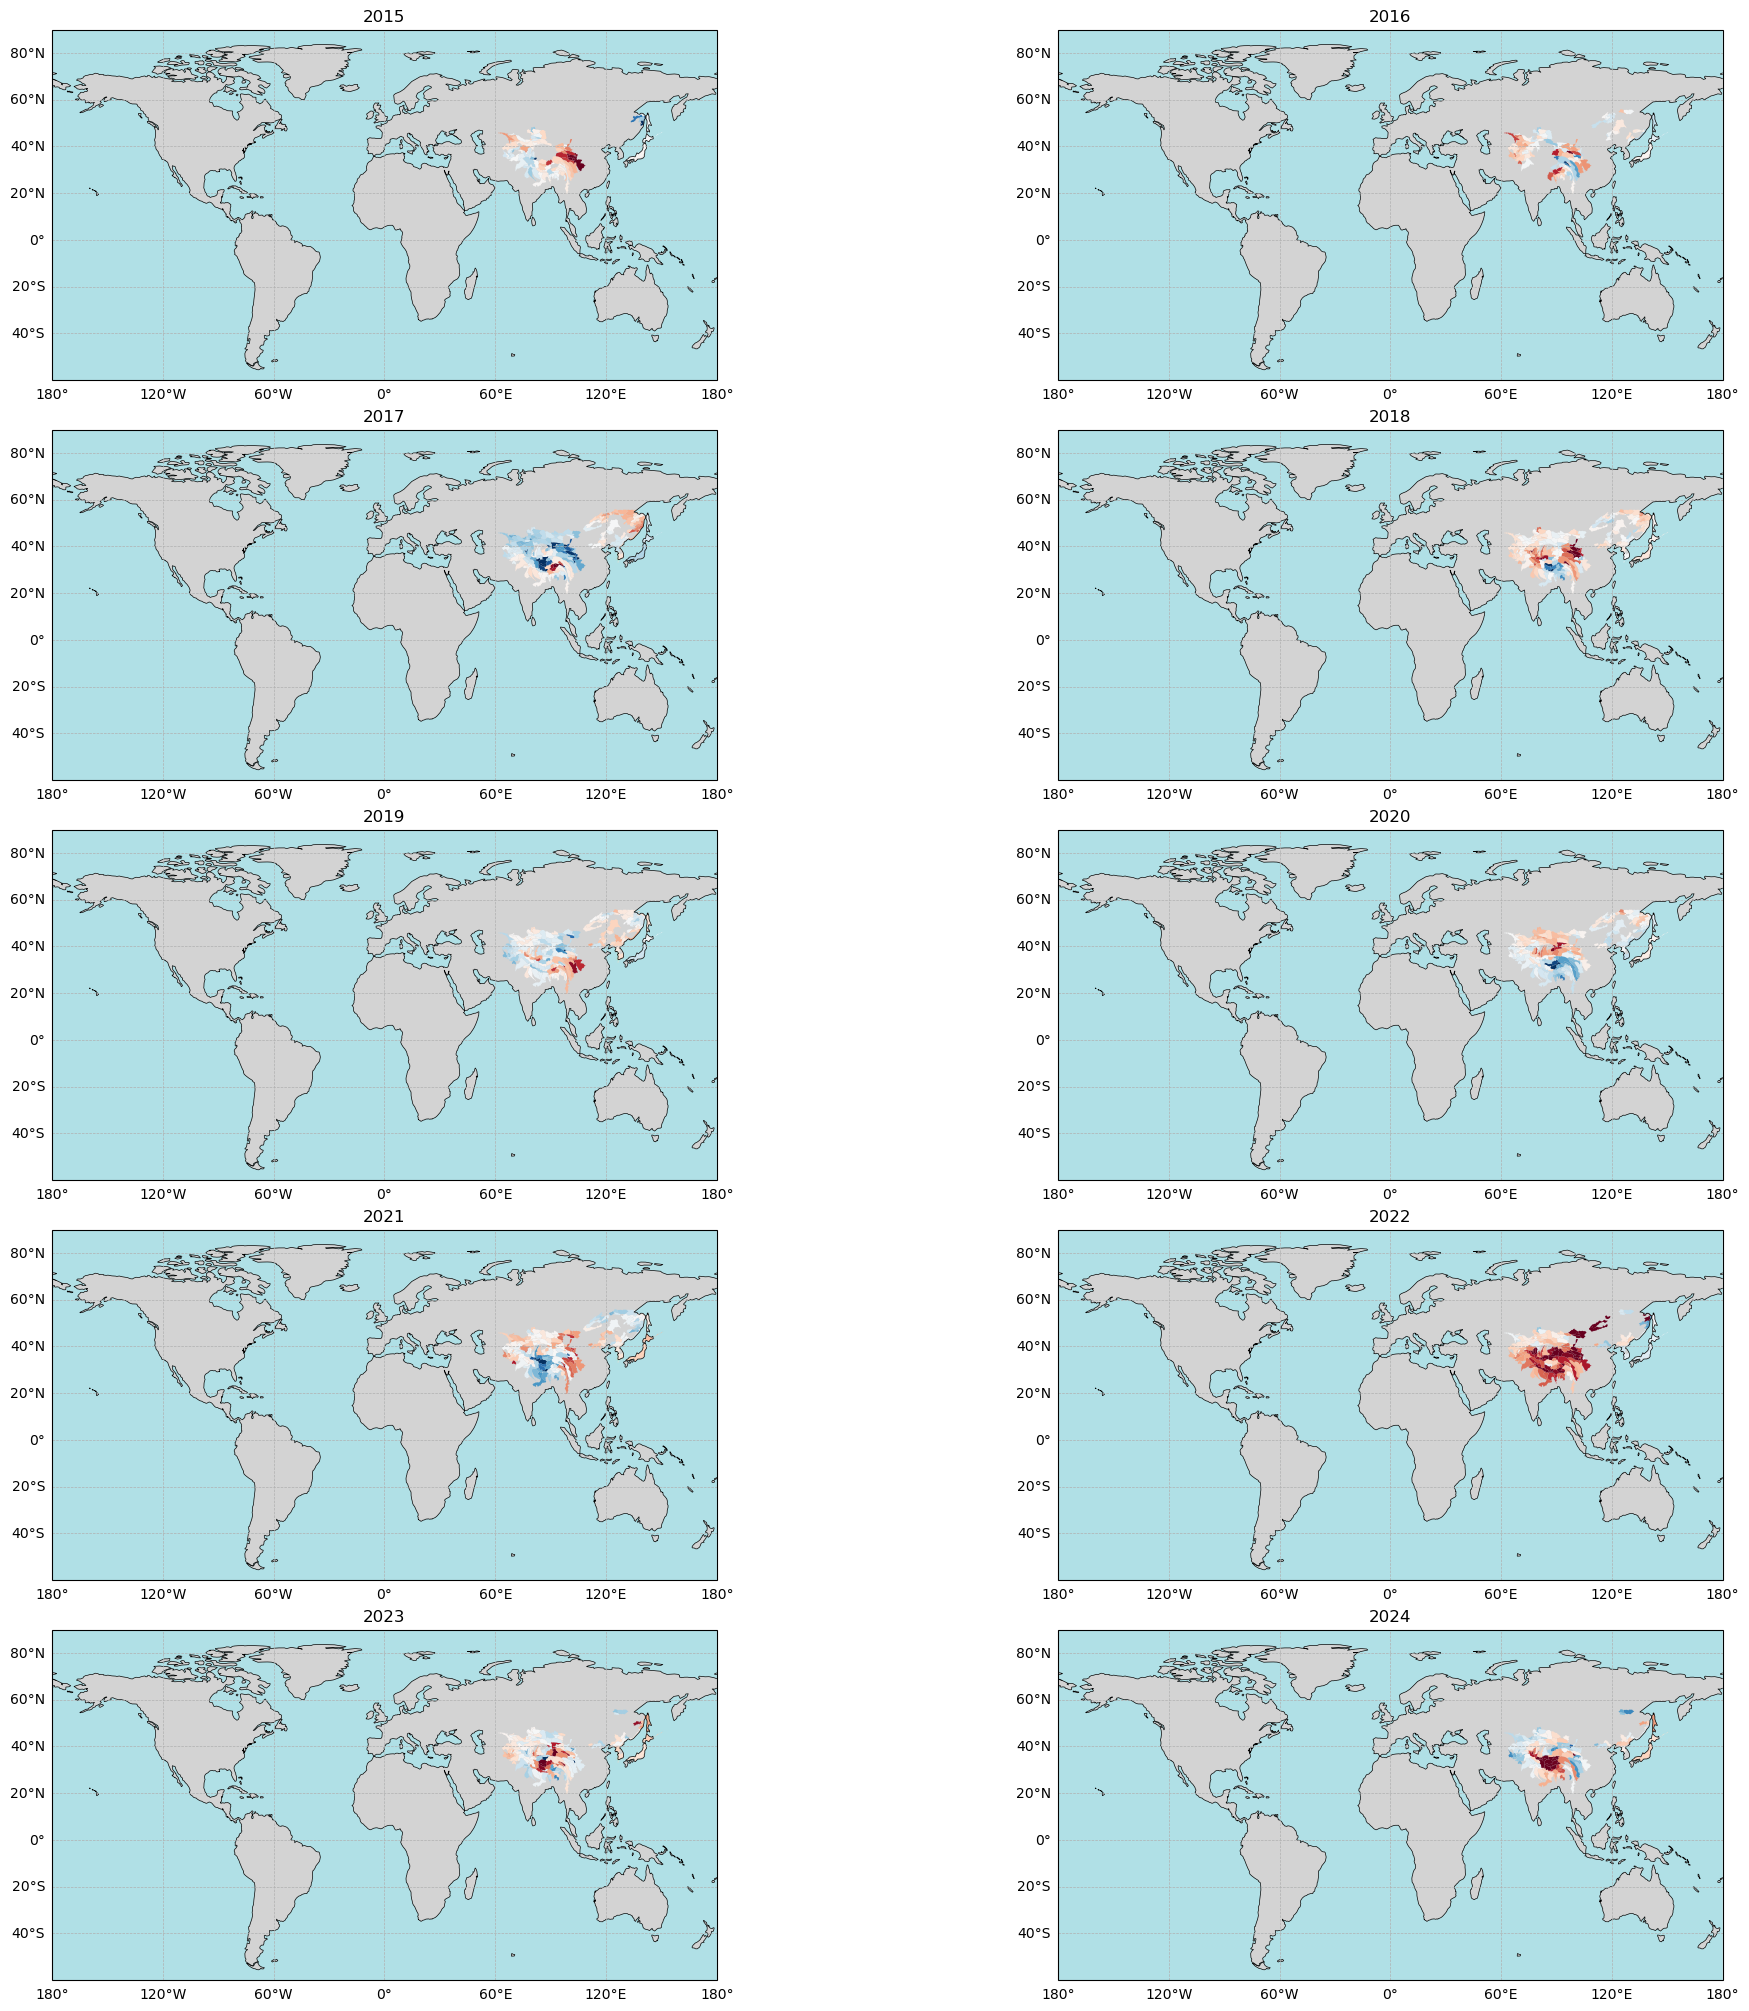

In [55]:
f,ax=plt.subplots(nrows=5,ncols=2,figsize=(20,20),subplot_kw={'projection': ccrs.PlateCarree()},layout='constrained', sharex=True, sharey=True) # ccrs.Robinson()

for water_year, ax in zip(weighted_mean_filtered_ds.water_year.values, ax.flat):
    basins_means_gdf.plot(ax=ax,column=f'runoff_onset_anomaly_WY{water_year}',cmap='RdBu',vmin=-30,vmax=30,transform=ccrs.PlateCarree())
    ax.set_title(f'{water_year}')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, xlocs=[-180, -120, -60, 0, 60, 120, 180], ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], linestyle='--', linewidth=0.5)
    gl.top_labels=False
    gl.bottom_labels=True
    gl.right_labels=False
    gl.left_labels=True

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')

#f.suptitle('Runoff Onset Anomaly by River Basin')
# f.tight_layout()

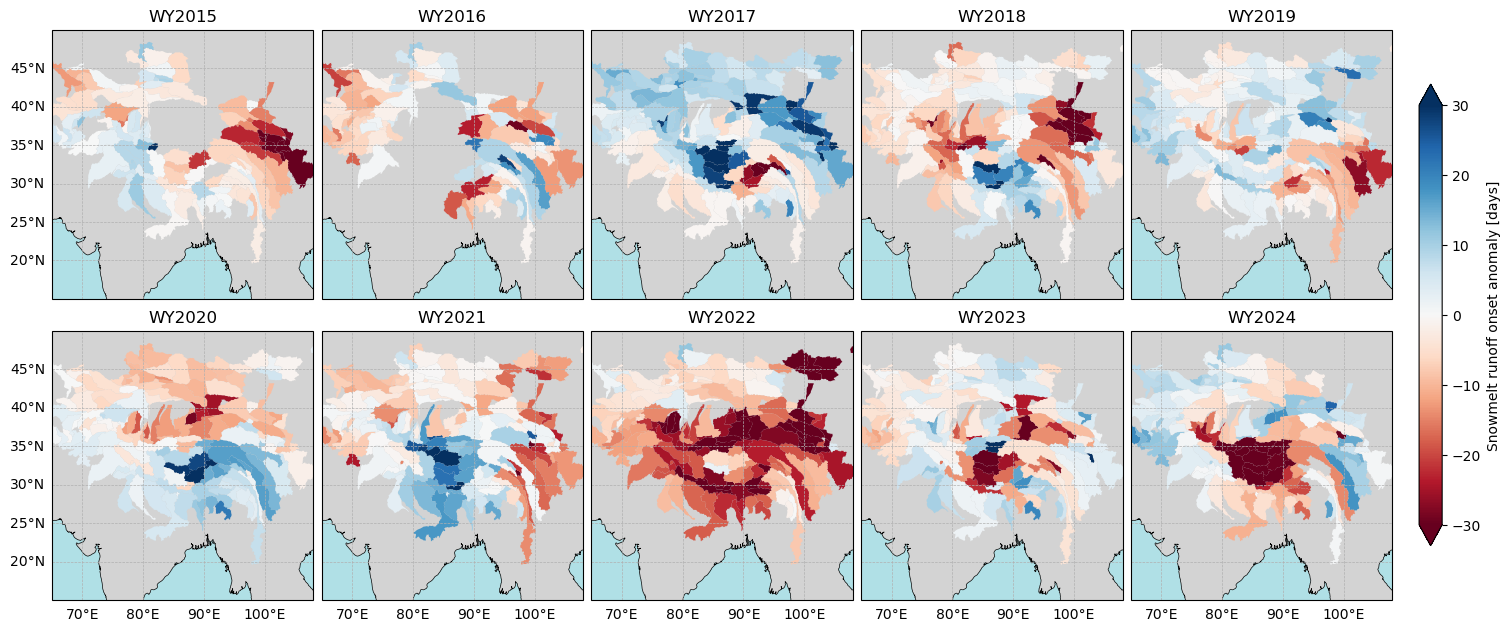

In [70]:
f,axes=plt.subplots(nrows=2,ncols=5,figsize=(15,6.2),subplot_kw={'projection': ccrs.PlateCarree()},layout='constrained', sharex=True, sharey=True) # ccrs.Robinson()

for water_year, ax in zip(weighted_mean_filtered_ds.water_year.values, axes.flat):
    basins_means_gdf.plot(ax=ax,column=f'runoff_onset_anomaly_WY{water_year}',cmap='RdBu',vmin=-30,vmax=30,transform=ccrs.PlateCarree())
    ax.set_title(f'WY{water_year}')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', linewidth=0.5)
    gl.top_labels=False
    # gl.bottom_labels=True
    gl.right_labels=False
    # gl.left_labels=True

    # turn on left labels for WY2015 and WY2020 only, turn on bottom labels for WY 2020-WY2024
    if water_year == 2015 or water_year == 2020:
        gl.left_labels = True
    else:
        gl.left_labels = False
    if water_year in [2020, 2021, 2022, 2023, 2024]:
        gl.bottom_labels = True
    else:
        gl.bottom_labels = False

    ax.set_extent([65, 108, 15, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')

# Add a single colorbar spanning both rows
import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=-30, vmax=30)
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=norm)
sm.set_array([])
cbar = f.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.8, aspect=20, pad=0.02, extend='both')
cbar.set_label('Snowmelt runoff onset anomaly [days]')

#f.suptitle('Runoff Onset Anomaly by River Basin')
# f.tight_layout()

In [ ]:
# bring in ERA5-Land SWE
# crop to basins
# wscatterplot SWE vs MAD per basin? order my SWE amount at peak?

In [ ]:
hemisphere = "NH" # "NH" or "SH"
water_year = 2015
water_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

datasets = []

for water_year in water_years:

    april1_date = f"{water_year}-04-01"
    nh_bbox_input = (-180,0,180,90)

    era5_land_swe_nh_da = easysnowdata.hydroclimatology.get_era5(
                                                            version="ERA5_LAND",
                                                            bbox_input=nh_bbox_input,
                                                            cadence="DAILY",
                                                            start_date=april1_date,
                                                            end_date=april1_date,
                                                            variables="snow_depth_water_equivalent")["snow_depth_water_equivalent"]

    era5_land_swe_nh_da = era5_land_swe_nh_da.assign_coords(
        water_year=era5_land_swe_nh_da.time.dt.year
    ).swap_dims(
        {"time": "water_year"}
    ).drop_vars("time")


    october1_date = f"{water_year}-10-01"
    sh_bbox_input = (-180,-90,180,0)

    era5_land_swe_sh_da = easysnowdata.hydroclimatology.get_era5(
                                                            version="ERA5_LAND",
                                                            bbox_input=sh_bbox_input,
                                                            cadence="DAILY",
                                                            start_date=october1_date,
                                                            end_date=october1_date,
                                                            variables="snow_depth_water_equivalent")["snow_depth_water_equivalent"]

    era5_land_swe_sh_da = era5_land_swe_sh_da.assign_coords(
        water_year=era5_land_swe_sh_da.time.dt.year
    ).swap_dims(
        {"time": "water_year"}
    ).drop_vars("time")

    datasets.append(xr.merge([era5_land_swe_nh_da, era5_land_swe_sh_da])["snow_depth_water_equivalent"].squeeze())

era5_land_swe_da = xr.concat(datasets, dim='water_year')
era5_land_swe_da = era5_land_swe_da.where(lambda x: x >= 0)
era5_land_swe_da

In [ ]:
era5_land_swe_da.plot.imshow(col='water_year', col_wrap=5, vmin=0, vmax=1, cmap='Blues', add_colorbar=True, cbar_kwargs={'label': 'SWE [m]'})

In [ ]:
era5_land_swe_median_da = era5_land_swe_da.median(dim='water_year')
era5_land_swe_median_da

In [ ]:
era5_land_swe_anomaly_da = era5_land_swe_da - era5_land_swe_median_da
era5_land_swe_anomaly_da.plot.imshow(col='water_year', col_wrap=2, aspect=2, add_colorbar=True, vmin=-0.4, vmax=0.4, cmap='RdBu', cbar_kwargs={'label': 'SWE anomaly [m]'})

In [ ]:
era5_land_swe_pct_norm_da = 100*(era5_land_swe_da/era5_land_swe_median_da)
era5_land_swe_pct_norm_da.plot.imshow(col='water_year', col_wrap=2, aspect=2, add_colorbar=True, vmin=50, vmax=150, cmap='RdBu', cbar_kwargs={'label': 'SWE pct norm [%]'})

In [ ]:
# basin = 21302
# f,ax=plt.subplots(figsize=(10,10)) # ccrs.Robinson()
# era5_land_swe_pct_norm_da.isel(water_year=0).rio.clip(basins_means_gdf[basins_means_gdf['PFAF_ID'] == basin].geometry.values, crs=basins_means_gdf.crs).plot.imshow(ax=ax, cmap='RdBu', add_colorbar=True, cbar_kwargs={'label': 'SWE pct norm [%]'})
# #era5_land_swe_median_da.rio.clip(basins_means_gdf[basins_means_gdf['PFAF_ID'] == basin].geometry.values, crs=basins_means_gdf.crs).plot.imshow(ax=ax, add_colorbar=True, cbar_kwargs={'label': 'SWE pct norm [%]'})

# basins_means_gdf[basins_means_gdf['PFAF_ID'] == basin].plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)

In [ ]:
R = 6.371e6

dϕ = np.deg2rad(0.1)
dλ = np.deg2rad(0.1)

dlat = R * dϕ * xr.ones_like(era5_land_swe_da['longitude'])
dlon = R * dλ * np.cos(np.deg2rad(era5_land_swe_da['latitude']))
dlon.name = "dlon"
dlat.name = "dlat"

cell_area_m_da = dlon * dlat
cell_area_m_da=cell_area_m_da.rio.write_crs(era5_land_swe_da.rio.crs)
cell_area_km_da = cell_area_m_da / 1e6

surface_area = cell_area_km_da.sum()
print(f"Total surface area of the dataset: {surface_area.values:,.0f} km²")


cell_area_km_da

In [ ]:
# Initialize with high volume endpoint
ee.Initialize(project="egagli-data-access", 
              opt_url='https://earthengine-highvolume.googleapis.com')

# Create yearly sums ImageCollection as before
variables = ["snowfall_sum", "total_precipitation_sum"]
image_collection = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR").select(variables)

start_year = 1950
end_year = 2024

def process_year(year):
    start_date = ee.Date.fromYMD(year, 1, 1)
    end_date = ee.Date.fromYMD(year, 12, 31)
    
    # Filter images for this year
    yearly_collection = image_collection.filterDate(start_date, end_date)
    
    # Sum monthly values to get annual totals
    yearly_sum = yearly_collection.sum()
    
    # Add year as a property
    return yearly_sum.set('year', year)

# Generate list of years and map the function over each year
years = range(start_year, end_year + 1)
yearly_sums = ee.ImageCollection(list(map(lambda y: process_year(y), years)))


mean_image = yearly_sums.mean()

snowfall = mean_image.select('snowfall_sum')
total_precip = mean_image.select('total_precipitation_sum')

valid_precip = total_precip.gt(0)  # Mask where precip > 0
pct_snow = snowfall.divide(total_precip).multiply(100).updateMask(valid_precip)
pct_snow = pct_snow.reproject(crs=image_collection.first().projection())
pct_snow = pct_snow.rename('percent_snow')


projection = pct_snow.projection()

pct_precip_as_snow_da = xr.open_dataset(
    ee.ImageCollection(pct_snow),
    engine='ee',
    projection=projection,

)['percent_snow'].squeeze().compute()

pct_precip_as_snow_da

In [ ]:
pct_precip_as_snow_da = (pct_precip_as_snow_da
        .transpose('lat', 'lon')
        .rename({'lat': 'latitude', 'lon': 'longitude'})
        .rio.set_spatial_dims(x_dim='longitude', y_dim='latitude'))
pct_precip_as_snow_da

In [ ]:
f,ax=plt.subplots(figsize=(12,6), subplot_kw={'projection': ccrs.Robinson()}, dpi=300, layout='constrained')

# Plot the data
# Define the color scheme similar to the one in the image
# Define the color scheme
colors = ['#7F00FF', '#5000FF', '#2E00FF', '#0000FF', '#003AFF', '#0075FF', 
          '#00AFFF', '#00C8C8', '#00E282', '#37FF00', '#69FF00', '#A0FF00',
          '#D7FF00', '#FFDC00', '#FFA500', '#FF6B00', '#FF3200', '#FF0000', '#FF0080']

# Create custom colormap
cmap = matplotlib.colors.LinearSegmentedColormap.from_list('custom_cmap', colors)
cmap.set_under('white')  # This sets values below vmin to white

# Set the levels for the color scale
levels = np.arange(0, 105, 5)  # 0, 5, 10, 15, ..., 95


plot = pct_precip_as_snow_da.plot(ax=ax, transform=ccrs.PlateCarree(),
               #cmap=cmap, levels=levels, 
               cmap='Purples',
               cbar_kwargs={'label': 'Percentage [%]'},
               add_colorbar=True)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.coastlines()

ax.set_title('Percentage of annual water-equivalent precipitation that falls as snow')


In [ ]:
# for each basin, add SWE median, SWE for each water year, and SWE anomaly for each water year from the era5_land_swe_da cropped to the basin

for i,basin in enumerate(basins_means_gdf['PFAF_ID'].values):
    print(f"Processing basin {basin}... {i+1}/{len(basins_means_gdf['PFAF_ID'].values)}")

    basin_swe_da = era5_land_swe_da.rio.clip(basins_means_gdf[basins_means_gdf['PFAF_ID'] == basin].geometry.values, crs=basins_means_gdf.crs)
    basin_swe_median_da = basin_swe_da.median(dim='water_year')
    basin_swe_anomaly_da = basin_swe_da - basin_swe_median_da
    basin_swe_pct_norm_da = 100*(basin_swe_da/basin_swe_median_da)

    basin_pct_precip_as_snow_da = pct_precip_as_snow_da.rio.clip(basins_means_gdf[basins_means_gdf['PFAF_ID'] == basin].geometry.values, crs=basins_means_gdf.crs)

    basin_cell_area_da = cell_area_km_da.rio.clip(basins_means_gdf[basins_means_gdf['PFAF_ID'] == basin].geometry.values, crs=basins_means_gdf.crs)
    basin_water_volume_da = ((basin_swe_da/1000) * basin_cell_area_da) # convert to km3
    basin_median_water_volume_da = basin_water_volume_da.median(dim='water_year')
    basin_water_volume_anomaly_da = basin_water_volume_da - basin_median_water_volume_da


#   basin_swe_sum_da = basin_swe_da.sum(dim='water_year') some sort of sum and median sum (total water from snow)

    basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, 'pct_precip_as_snow'] = basin_pct_precip_as_snow_da.where(lambda x: x>0).mean().values
    basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, 'swe_median'] = basin_swe_median_da.mean().values
    basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, 'median_total_water_equivalent_km3'] = basin_median_water_volume_da.mean().values


    for water_year in water_years:
        basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, f'swe_WY{water_year}'] = basin_swe_da.sel(water_year=water_year).mean().values
        basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, f'swe_anomaly_WY{water_year}'] = basin_swe_anomaly_da.sel(water_year=water_year).mean().values
        basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, f'swe_pct_norm_WY{water_year}'] = basin_swe_pct_norm_da.sel(water_year=water_year).mean().values

        basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, f'total_water_equivalent_km3_WY{water_year}'] = basin_water_volume_da.sel(water_year=water_year).mean().values
        basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, f'total_water_equivalent_anomaly_km3_WY{water_year}'] = basin_water_volume_anomaly_da.sel(water_year=water_year).mean().values
        basins_means_gdf.loc[basins_means_gdf['PFAF_ID'] == basin, f'total_water_equivalent_pct_norm_WY{water_year}'] = (basin_water_volume_da.sel(water_year=water_year)/basin_median_water_volume_da).mean().values

In [ ]:
basins_means_gdf.plot(column='swe_median',legend=True, cmap='Blues', legend_kwds={'label': "SWE median [m]"},vmin=0,vmax=1)

In [ ]:
basins_means_gdf.plot(column='pct_precip_as_snow',legend=True, cmap='Purples', legend_kwds={'label': "Percent of precip that falls as snow [%]"},vmin=0,vmax=100)

In [ ]:
f,ax=plt.subplots(figsize=(12,7))
basins_means_gdf.plot.scatter(ax=ax,x='POPULATION',y='pct_precip_as_snow',c='runoff_onset_mad',cmap='Reds',edgecolor='black',linewidth=0.5)
# make x axis log scale
ax.set_xscale('log')

In [ ]:
f,axs=plt.subplots(nrows=5,ncols=2, figsize=(10,10), subplot_kw={'projection': ccrs.PlateCarree()}, dpi=300, layout='constrained',sharex=True, sharey=True)

for water_year, ax in zip(water_years,axs.flat):
    basins_means_gdf.plot(ax=ax,column=f'swe_anomaly_WY{water_year}',cmap='RdBu',vmin=-0.5,vmax=0.5,legend=False, transform=ccrs.PlateCarree())
    ax.set_title(f'{water_year}')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, xlocs=[-180, -120, -60, 0, 60, 120, 180], ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], linestyle='--', linewidth=0.5)
    gl.top_labels=False
    gl.bottom_labels=True
    gl.right_labels=False
    gl.left_labels=True

    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')

In [ ]:
#basins_means_gdf.explore(column='swe_median',vmin=0,vmax=2)

In [ ]:
f,ax=plt.subplots(figsize=(10,10))
basins_means_gdf.plot.scatter(ax=ax,y='swe_median',x='runoff_onset_median',c='runoff_onset_mad',cmap='Reds',vmin=0,vmax=30,alpha=1, s=10)
ax.set_ylim(0,3)
ax.set_xlabel("10-year median runoff onset date [DOWY]")
ax.set_ylabel("10-year median April 1st / October 1st SWE [m]")

In [ ]:
f,ax=plt.subplots(figsize=(10,10))
basins_means_gdf.plot.scatter(ax=ax,y='swe_median',x='runoff_onset_mad',c='runoff_onset_median', cmap='viridis',s=10)
ax.set_ylim(0,3)
ax.set_xlabel("10-year runoff onset median absolute deivations [days]")
ax.set_ylabel("10-year median April 1st / October 1st SWE [m]")
# which basins have a high SWE and low MAD?
# which basins have a high SWE and high MAD (more dangerous)

In [ ]:
# f,ax=plt.subplots(figsize=(12,7))
# basins_means_gdf['POPULATION'].hist(ax=ax,bins=300)
# ax.set_ylim(0,100)

In [ ]:
# basins_means_gdf[basins_means_gdf['POPULATION'] == 0].explore()

In [ ]:
sizes = np.log(basins_means_gdf['POPULATION']+1)
sizes

In [ ]:
f,ax=plt.subplots(figsize=(12,7))
sizes.hist(ax=ax,bins=300)
#ax.set_ylim(0,100)

In [ ]:
f,ax=plt.subplots(figsize=(10,10))
basins_means_gdf.plot.scatter(ax=ax,y='swe_median',x='runoff_onset_mad',c='runoff_onset_median', cmap='viridis',s=5*sizes)
ax.set_ylim(0,3) # 0.1,0.5,1
ax.set_xlabel("10-year runoff onset median absolute deivations [days]")
ax.set_ylabel("10-year median April 1st / October 1st SWE [m]")
# which basins have a high SWE and low MAD?
# which basins have a high SWE and high MAD (more dangerous)

In [ ]:
f,ax=plt.subplots(figsize=(10,10))
basins_means_gdf.plot.scatter(ax=ax,y='swe_median',x='runoff_onset_median',c='runoff_onset_mad',cmap='Reds',vmin=0,vmax=30,alpha=1, s=sizes)
ax.set_ylim(0,3)
ax.set_xlabel("10-year median runoff onset date [DOWY]")
ax.set_ylabel("10-year median April 1st / October 1st SWE [m]")

In [ ]:
# maybe focus on population on x axis????
# 
# f,ax=plt.subplots(figsize=(10,10))
basins_means_gdf.plot.scatter(ax=ax,y='swe_median',x='runoff_onset_median',c='runoff_onset_mad',cmap='Reds',vmin=0,vmax=30,alpha=1, s=sizes)
ax.set_ylim(0,3)
ax.set_xlabel("10-year median runoff onset date [DOWY]")
ax.set_ylabel("10-year median April 1st / October 1st SWE [m]")

In [ ]:
basins_means_gdf.columns

In [ ]:
f,ax=plt.subplots(figsize=(10,10))
basins_means_gdf.plot.scatter(ax=ax,y='median_total_water_equivalent_km3',x='runoff_onset_mad',c='runoff_onset_median', cmap='viridis',s=5*sizes)
ax.set_xlabel("10-year runoff onset median absolute deivations [days]")
ax.set_ylabel("10-year median April 1st / October 1st total water equivalent [km^3]")
# which basins have a high SWE and low MAD?
# which basins have a high SWE and high MAD (more dangerous)

In [ ]:
basins_means_gdf['swe_median'].describe()

In [ ]:
scatter_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
f,ax=plt.subplots(figsize=(10,10))

for water_year, color in zip(water_years,scatter_colors):
    basins_means_gdf[basins_means_gdf['swe_median']>0.0].plot.scatter(ax=ax,y=f'swe_anomaly_WY{water_year}',x=f'runoff_onset_anomaly_WY{water_year}',color=color,s=1,alpha=1,label=water_year)



ax.axvline(x=0, color='black', linestyle='--')
ax.axhline(y=0, color='black', linestyle='--')

ax.set_ylim(-0.5,0.5)
ax.set_xlim(-30,30)

ax.set_xlabel("Runoff onset anomaly [days]")
ax.set_ylabel("SWE anomaly [m]")

ax.legend()


In [ ]:
scatter_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
f,ax=plt.subplots(figsize=(10,10))

for water_year, color in zip(water_years,scatter_colors):
    basins_means_gdf[basins_means_gdf['swe_median']>0.0].plot.scatter(ax=ax,y=f'total_water_equivalent_anomaly_km3_WY{water_year}',x=f'runoff_onset_anomaly_WY{water_year}',color=color,s=1,alpha=1,label=water_year)



ax.axvline(x=0, color='black', linestyle='--')
ax.axhline(y=0, color='black', linestyle='--')

#ax.set_ylim(-0.5,0.5)
ax.set_xlim(-30,30)

ax.set_xlabel("Runoff onset anomaly [days]")
ax.set_ylabel("Basin total water volume anomaly [km^3]")

ax.legend()

In [ ]:
# Define water years
water_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# Create empty list to store data rows
data_rows = []

# Filter to basins with SWE median > 0.0 as in your previous analyses
filtered_data = basins_means_gdf[basins_means_gdf['swe_median'] > 0.0]

# Loop through each basin
for idx, basin_row in filtered_data.iterrows():
    basin_id = basin_row['PFAF_ID']  # Using PFAF_ID as basin identifier
    
    # For each water year, extract the anomaly values
    for year in water_years:
        runoff_col = f'runoff_onset_anomaly_WY{year}'
        swe_col = f'swe_anomaly_WY{year}'
        
        # Check if columns exist and values are not NaN
        if runoff_col in filtered_data.columns and swe_col in filtered_data.columns:
            runoff_anomaly = basin_row[runoff_col] 
            swe_anomaly = basin_row[swe_col]
            
            # Only include rows where both values are valid
            if pd.notna(runoff_anomaly) and pd.notna(swe_anomaly):
                data_rows.append({
                    'basin': basin_id,
                    'runoff_onset_anomaly': runoff_anomaly,
                    'swe_anomaly': swe_anomaly,
                    'water_year': year
                })

# Create dataframe from collected data
anomalies_df = pd.DataFrame(data_rows)
anomalies_df

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Create figure for KDE plot
fig_kde, ax_kde = plt.subplots(figsize=(10, 10))

# Create the KDE plot
sns.kdeplot(
    data=anomalies_df,
    x='runoff_onset_anomaly',
    y='swe_anomaly',
    fill=True,
    cmap="viridis",
    levels=30,
    ax=ax_kde
)

# Calculate line of best fit
slope, intercept, r_value, p_value, std_err = stats.linregress(
    anomalies_df['runoff_onset_anomaly'].dropna(), 
    anomalies_df['swe_anomaly'].dropna()
)

# Add line of best fit to KDE plot
x_line = np.linspace(-30, 30, 100)
y_line = slope * x_line + intercept
ax_kde.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, 
            label=f'y = {slope:.4f}x + {intercept:.4f} (r = {r_value:.2f})')

# Add reference lines
ax_kde.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax_kde.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Set limits and labels
ax_kde.set_ylim(-0.3, 0.3)
ax_kde.set_xlim(-30, 30)
ax_kde.set_xlabel('Runoff Onset Anomaly [days]')
ax_kde.set_ylabel('SWE Anomaly [m]')
ax_kde.set_title('KDE Plot of SWE vs Runoff Onset Anomalies')
ax_kde.legend()

# Create figure for hexbin plot
fig_hex, ax_hex = plt.subplots(figsize=(10, 10))

# Create the hexbin plot
hb = ax_hex.hexbin(
    anomalies_df['runoff_onset_anomaly'], 
    anomalies_df['swe_anomaly'], 
    gridsize=100, 
    cmap='viridis', 
    mincnt=1,
    bins='log'  # Use log scale for better visualization
)

# Add line of best fit to hexbin plot
ax_hex.plot(x_line, y_line, color='red', linestyle='--', linewidth=2,
            label=f'y = {slope:.4f}x + {intercept:.4f} (r = {r_value:.2f})')

# Add reference lines
ax_hex.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax_hex.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Set limits and labels
ax_hex.set_ylim(-0.3, 0.3)
ax_hex.set_xlim(-30, 30)
ax_hex.set_xlabel('Runoff Onset Anomaly [days]')
ax_hex.set_ylabel('SWE Anomaly [m]')
ax_hex.set_title('Hexbin Plot of SWE vs Runoff Onset Anomalies')
ax_hex.legend()

# Add colorbar to hexbin plot
cb = fig_hex.colorbar(hb, ax=ax_hex)
cb.set_label('log10(count)')

plt.tight_layout()
plt.show()

In [ ]:
scatter_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
f,ax=plt.subplots(figsize=(10,10))

for water_year, color in zip(water_years,scatter_colors):
    basins_means_gdf.plot.scatter(ax=ax,y=f'swe_pct_norm_WY{water_year}',x=f'runoff_onset_anomaly_WY{water_year}',color=color,s=1, alpha=1)

ax.set_ylim(0,1000)
ax.set_xlim(-60,60)

# ax.set_ylim(0)
# ax.set_xlim(-30,30)

ax.axvline(x=0, color='black', linestyle='--')
ax.axhline(y=100, color='black', linestyle='--')

In [ ]:
basins_means_gdf

In [ ]:
# Define water years
water_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

# Create empty list to store data rows
data_rows = []

# Filter to basins with SWE median > 0.0 as in your previous analyses
filtered_data = basins_means_gdf[basins_means_gdf['swe_median'] > 0.0]

# Loop through each basin
for idx, basin_row in filtered_data.iterrows():
    basin_id = basin_row['PFAF_ID']  # Using PFAF_ID as basin identifier
    
    # For each water year, extract the anomaly values
    for year in water_years:
        runoff_col = f'runoff_onset_anomaly_WY{year}'
        swe_col = f'total_water_equivalent_anomaly_km3_WY{year}'
        
        # Check if columns exist and values are not NaN
        if runoff_col in filtered_data.columns and swe_col in filtered_data.columns:
            runoff_anomaly = basin_row[runoff_col] 
            swe_anomaly = basin_row[swe_col]
            
            # Only include rows where both values are valid
            if pd.notna(runoff_anomaly) and pd.notna(swe_anomaly):
                data_rows.append({
                    'basin': basin_id,
                    'runoff_onset_anomaly': runoff_anomaly,
                    'basin_total_water_volume_anomaly': swe_anomaly,
                    'water_year': year
                })

# Create dataframe from collected data
anomalies_df = pd.DataFrame(data_rows)
anomalies_df

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Create figure for KDE plot
fig_kde, ax_kde = plt.subplots(figsize=(10, 10))

# Create the KDE plot
sns.kdeplot(
    data=anomalies_df,
    x='runoff_onset_anomaly',
    y='basin_total_water_volume_anomaly',
    fill=True,
    cmap="viridis",
    levels=30,
    ax=ax_kde
)

# Calculate line of best fit
slope, intercept, r_value, p_value, std_err = stats.linregress(
    anomalies_df['runoff_onset_anomaly'].dropna(), 
    anomalies_df['basin_total_water_volume_anomaly'].dropna()
)

# Add line of best fit to KDE plot
x_line = np.linspace(-30, 30, 100)
y_line = slope * x_line + intercept
ax_kde.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, 
            label=f'y = {slope:.4f}x + {intercept:.4f} (r = {r_value:.2f})')

# Add reference lines
ax_kde.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax_kde.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Set limits and labels
#ax_kde.set_ylim(-0.3, 0.3)
ax_kde.set_xlim(-30, 30)
ax_kde.set_xlabel('Runoff Onset Anomaly [days]')
ax_kde.set_ylabel('Basin total water volume anomaly [km^3]')
ax_kde.set_title('KDE Plot of Basin Total Water Volume Anomalies vs Runoff Onset Anomalies')
ax_kde.legend()

# Create figure for hexbin plot
fig_hex, ax_hex = plt.subplots(figsize=(10, 10))

# Create the hexbin plot
hb = ax_hex.hexbin(
    anomalies_df['runoff_onset_anomaly'], 
    anomalies_df['basin_total_water_volume_anomaly'], 
    gridsize=100, 
    cmap='viridis', 
    mincnt=1,
    bins='log'  # Use log scale for better visualization
)

# Add line of best fit to hexbin plot
ax_hex.plot(x_line, y_line, color='red', linestyle='--', linewidth=2,
            label=f'y = {slope:.4f}x + {intercept:.4f} (r = {r_value:.2f})')

# Add reference lines
ax_hex.axvline(x=0, color='black', linestyle='--', alpha=0.5)
ax_hex.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Set limits and labels
#ax_hex.set_ylim(-0.3, 0.3)
ax_hex.set_xlim(-30, 30)
ax_hex.set_xlabel('Runoff Onset Anomaly [days]')
ax_hex.set_ylabel('Basin total water volume anomaly [km^3]')
ax_hex.set_title('Hexbin Plot of Basin Total Water Volume Anomalies vs Runoff Onset Anomalies')
ax_hex.legend()

# Add colorbar to hexbin plot
cb = fig_hex.colorbar(hb, ax=ax_hex)
cb.set_label('log10(count)')

plt.tight_layout()
plt.show()

In [ ]:
# f,ax=plt.subplots(nrows=5,ncols=2,figsize=(15,20),subplot_kw={'projection': ccrs.PlateCarree()}) # ccrs.Robinson()
# for water_year, ax in zip(weighted_mean_filtered_ds.water_year.values, ax.flat):
#     basins_counts_gdf.plot(ax=ax,column=f'runoff_onset_anomaly_WY{water_year}',transform=ccrs.PlateCarree(),norm=colors.LogNorm())
#     ax.set_title(f'{water_year}')
#     ax.coastlines()

# f.suptitle('Runoff Onset Anomaly runoff onset pixel counts by River Basin')
# f.tight_layout()

# f,ax=plt.subplots(nrows=5,ncols=2,figsize=(15,20),subplot_kw={'projection': ccrs.PlateCarree()}) # ccrs.Robinson()
# for water_year, ax in zip(weighted_mean_filtered_ds.water_year.values, ax.flat):
#     basins_areas_gdf.plot(ax=ax,column=f'runoff_onset_anomaly_WY{water_year}',transform=ccrs.PlateCarree())
#     ax.set_title(f'{water_year}')
#     ax.coastlines()

# f.suptitle('Runoff Onset Anomaly runoff onset pixel areas by River Basin')
# f.tight_layout()

# f,ax=plt.subplots(nrows=5,ncols=2,figsize=(15,20),subplot_kw={'projection': ccrs.PlateCarree()}) # ccrs.Robinson()
# for water_year, ax in zip(weighted_mean_filtered_ds.water_year.values, ax.flat):
#     basins_pct_areas_gdf.plot(ax=ax,column=f'runoff_onset_anomaly_WY{water_year}',transform=ccrs.PlateCarree(),vmin=0,vmax=100,cmap='gist_stern') # cmap='rainbow'
#     ax.set_title(f'{water_year}')
#     ax.coastlines()

# f.suptitle('Runoff Onset Anomaly pct area with runoff onset pixels by River Basin')
# f.tight_layout()

In [ ]:
# Load and prepare world data


In [ ]:
def basin_stats(id,basins_gdf):
    try:
        print(f'Processing basin {id}...')
        basin_gdf = basins_gdf[basins_gdf['BASWC4_ID'] == id]


        print('Clipping data to basin box...')
        global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')
        global_clipbox_ds = global_ds.rio.clip_box(*basin_gdf.total_bounds)

        print('Clipping data to basin geometry...')
        basin_ds = global_clipbox_ds.rio.clip(basin_gdf.geometry)

        basin_ds['runoff_onset_anomaly'] = basin_ds['runoff_onset'] - basin_ds['runoff_onset_median']
        
        print('Computing basin stats...')
        stats_ds = basin_ds.mean(dim=['latitude','longitude'])

        stats_ds.attrs['BASWC4_ID'] = id

        return stats_ds.compute()
    
    except Exception as e:
        print(e)
        return e, id

In [ ]:
cluster = coiled.Cluster(idle_timeout="10 minutes",
                        n_workers=20, #10
                        worker_memory="64 GB", #32 # 128 and 32 almost worked
                        worker_cpu=8, # 4,
                        scheduler_memory="128 GB",
                        spot_policy="spot",
                        environ={"GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR"},
                        workspace="uwtacolab",
                        )

client = cluster.get_client()

In [ ]:
client.restart()

In [ ]:
futures = []

for id in basins_gdf['BASWC4_ID'].values:
    output_filename = f'aggregated_results/river_basins/basin_stats_{id}.nc'
    if not os.path.exists(output_filename):
        future = client.submit(basin_stats, id, basins_gdf)
        futures.append(future)
    else:
        print(f'Skipping basin {id}...')

In [ ]:
futures

In [ ]:
futures[0].result()

In [ ]:
for future, result in dask.distributed.as_completed(futures, with_results=True):

    print('-'*80)
    if type(result) == xr.Dataset:
        id = result.attrs['BASWC4_ID']
        output_filename = f'aggregated_results/river_basins/basin_stats_{id}.nc'
        result.to_netcdf(output_filename)
        print(f"Saved to {output_filename}")
    else:
        e, id = result
        print(f"Failed to process basin {id}")
        print(e)

In [ ]:
nc_files = sorted(glob.glob(f"aggregated_results/river_basins/basin_stats_*.nc"))
datasets = []

for nc_file in nc_files:
    ds = xr.open_dataset(nc_file,decode_times=False)
    mr_id = int(nc_file.split('_')[-1].split('.')[0])
    ds = ds.expand_dims({'basin': [mr_id]})
    datasets.append(ds)

merged_ds = xr.concat(datasets, dim='basin')
merged_ds

In [ ]:
merged_ds['runoff_onset'].sortby('basin').plot()

In [ ]:
merged_ds['runoff_onset']

In [ ]:
merged_ds

In [ ]:
id = 11

In [ ]:
for id in basins_gdf['BASWC4_ID'].values:
    try:
        basins_gdf.loc[basins_gdf['BASWC4_ID'] == id,'runoff_onset_median'] = merged_ds.sel(basin=id)['runoff_onset_median'].values
        basins_gdf.loc[basins_gdf['BASWC4_ID'] == id,'runoff_onset_mad'] = merged_ds.sel(basin=id)['runoff_onset_mad'].values
        for water_year in merged_ds.water_year.values:
            try:
                basins_gdf.loc[basins_gdf['BASWC4_ID'] == id,f'runoff_onset_{water_year}'] = merged_ds.sel(basin=id)['runoff_onset'].sel(water_year=water_year).values
                basins_gdf.loc[basins_gdf['BASWC4_ID'] == id,f'runoff_onset_anomaly_{water_year}'] = merged_ds.sel(basin=id)['runoff_onset_anomaly'].sel(water_year=water_year).values
            except:
                pass
    except Exception as e:
        print(e)
        print(f"No data for basin {id}")

In [ ]:
basins_gdf

In [ ]:
f,ax=plt.subplots(figsize=(10,5),layout='constrained',subplot_kw={'projection': ccrs.Robinson()})
basins_gdf.plot(ax=ax,column='runoff_onset_median',legend=True,legend_kwds={'label': "Day of Water Year"}, transform=ccrs.PlateCarree())
ax.set_title('Median Runoff Onset Day by Major River Basin')
ax.coastlines()

In [ ]:
f,ax=plt.subplots(figsize=(10,5),layout='constrained',subplot_kw={'projection': ccrs.Robinson()})
basins_gdf.plot(ax=ax,column='runoff_onset_mad',legend=True,legend_kwds={'label': "Days"}, transform=ccrs.PlateCarree(),cmap='Reds')
ax.set_title('Runoff Onset MAD by Major River Basin')
ax.coastlines()

In [ ]:
f,ax=plt.subplots(nrows=2,ncols=5,figsize=(20,6),subplot_kw={'projection': ccrs.Robinson()})
for water_year, ax in zip(global_ds.water_year.values, ax.flat):
    #f,ax=plt.subplots(figsize=(10,5),layout='constrained',subplot_kw={'projection': ccrs.Robinson()})
    basins_gdf.plot(ax=ax,column=f'runoff_onset_anomaly_{water_year}',cmap='RdBu',vmin=-30,vmax=30,transform=ccrs.PlateCarree())
    ax.set_title(f'{water_year}')
    ax.coastlines()

f.suptitle('Runoff Onset Anomaly by Major River Basin')
f.tight_layout()

In [ ]:
for water_year in global_ds.water_year.values:
    f,ax=plt.subplots(figsize=(10,5),layout='constrained',subplot_kw={'projection': ccrs.Robinson()})
    basins_gdf.plot(ax=ax,column=f'runoff_onset_anomaly_{water_year}',cmap='RdBu',vmin=-30,vmax=30,transform=ccrs.PlateCarree(), legend=True, legend_kwds={'label': "Days"})
    ax.set_title(f'{water_year} Runoff Onset Anomaly by Major River Basin')
    ax.coastlines()

In [ ]:
basins_gdf

In [ ]:
for id in basins_gdf['BASWC4_ID'].values:
    basin_gdf.loc['runoff_onset'] 


In [ ]:
basins_gdf

In [ ]:
basins_gdf.loc['runoff_onset_median']

In [ ]:
global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')
global_ds

In [ ]:
global_ds['runoff_onset_median'].xvec.zonal_stats(basins_gdf.geometry,x_coords="longitude",y_coords="latitude",n_jobs=-1)

In [ ]:
url = (f"https://data.earthenv.org/mountains/standard/GMBA_Inventory_v2.0_standard_300.zip")
gmba_gdf = gpd.read_file("zip+" + url)
gmba_gdf

In [ ]:
gmba_gdf.explore()

In [ ]:
import dask.delayed

#@dask.delayed
def process_and_save_mountain_range(mountain_range_id, parquet_path, filesystem, 
                                  dem_bin_low=0, dem_bin_high=9000, 
                                  dem_bin_interval=100, aspect_bin_interval=15):
    """Process single mountain range and save to netCDF"""
    #print(f'Processing mountain range {mountain_range_id}...')
    
    # Setup bins and coordinates
    dem_bins = np.arange(dem_bin_low, dem_bin_high+dem_bin_interval, dem_bin_interval)
    aspect_bins = np.arange(0, 360+aspect_bin_interval, aspect_bin_interval)
    water_years = range(2015, 2025)
    dem_coords = dem_bins[:-1] + dem_bin_interval/2
    aspect_coords = aspect_bins[:-1] + aspect_bin_interval/2
    stat_coords = ["mean", "median", "count"]

    # Read data
    cols_needed = ['GMBA_V2_ID', 'dem', 'aspect', 'runoff_onset_median', 'runoff_onset_mad'] + \
                  [f'runoff_onset_WY{year}' for year in water_years]
    
    range_ddf = dd.read_parquet(
        parquet_path,
        filesystem=filesystem,
        columns=cols_needed,
        #storage_options={"anon":       
        filters=[('GMBA_V2_ID', '==', mountain_range_id)]
    ).repartition(partition_size="100MB").persist()

    # Create bins and calculate anomalies
    def bin_and_anomaly(df):
        df = df.dropna(subset=['dem', 'aspect'])
        df['dem_bin'] = pd.cut(df['dem'], dem_bins).apply(lambda x: x.left+(dem_bin_interval/2) if pd.notnull(x) else np.nan)
        df['aspect_bin'] = pd.cut(df['aspect'], aspect_bins).apply(lambda x: x.left+(aspect_bin_interval/2) if pd.notnull(x) else np.nan)
        df['dem_bin'] = df['dem_bin'].astype('Int64')
        df['aspect_bin'] = df['aspect_bin'].astype('Float64')
        
        # Calculate anomalies
        for year in water_years:
            col = f'runoff_onset_WY{year}'
            anom_col = f'runoff_onset_anomaly_WY{year}'
            df[anom_col] = df[col].where(df[col] > 0) - df['runoff_onset_median']
        
        return df

    range_ddf = range_ddf.map_partitions(bin_and_anomaly)
    range_ddf = range_ddf.dropna(subset=['dem_bin', 'aspect_bin'])
    range_ddf = range_ddf.persist()

    # Calculate static statistics
    #print("Computing static aggregations...")
    agg_static = range_ddf.groupby(['dem_bin', 'aspect_bin']).agg({
        'runoff_onset_median': ['mean', 'median', 'count'],
        'runoff_onset_mad': ['mean', 'median', 'count']
    }).compute()

    #print("Computing yearly aggregations...")
    yearly_aggs = []
    anomaly_aggs = []
    
    for year in water_years:
        year_col = f'runoff_onset_WY{year}'
        # Filter out -9999 values
        year_data = range_ddf[range_ddf[year_col] > 0][['dem_bin', 'aspect_bin', year_col]]
        
        year_agg = year_data.groupby(['dem_bin', 'aspect_bin']).agg({
            year_col: ['mean', 'median', 'count']
        }).compute()
        
        year_agg.columns = ['mean', 'median', 'count']
        year_agg = year_agg.reset_index()
        year_agg['water_year'] = year
        yearly_aggs.append(year_agg)

        # Process anomaly data that was calculated earlier
        anom_col = f'runoff_onset_anomaly_WY{year}'
        anom_data = range_ddf.dropna(subset=[anom_col])[['dem_bin', 'aspect_bin', anom_col]]
        
        anom_agg = anom_data.groupby(['dem_bin', 'aspect_bin']).agg({
            anom_col: ['mean', 'median', 'count']
        }).compute()
        
        anom_agg.columns = ['mean', 'median', 'count']
        anom_agg = anom_agg.reset_index()
        anom_agg['water_year'] = year
        anomaly_aggs.append(anom_agg)

    # Convert to pandas DataFrames
    yearly_aggs = pd.concat(yearly_aggs, ignore_index=True)
    anomaly_aggs = pd.concat(anomaly_aggs, ignore_index=True)

    
    # Create dataset
    ds = xr.Dataset(
        coords={
            'elevation': dem_coords,
            'aspect': aspect_coords,
            'statistic': stat_coords,
            'water_year': list(water_years)
        }
    )

    # Initialize arrays
    shape_static = (len(ds.elevation), len(ds.aspect), len(ds.statistic))
    shape_yearly = shape_static + (len(ds.water_year),)

    ds['runoff_onset_median'] = xr.DataArray(np.full(shape_static, np.nan), 
        dims=('elevation', 'aspect', 'statistic'))
    ds['runoff_onset_mad'] = xr.DataArray(np.full(shape_static, np.nan), 
        dims=('elevation', 'aspect', 'statistic'))
    ds['runoff_onset'] = xr.DataArray(np.full(shape_yearly, np.nan), 
        dims=('elevation', 'aspect', 'statistic', 'water_year'))
    ds['runoff_onset_anomaly'] = xr.DataArray(np.full(shape_yearly, np.nan), 
        dims=('elevation', 'aspect', 'statistic', 'water_year'))

    # Fill values using pandas indexing
    for dem in ds.elevation.values:
        for asp in ds.aspect.values:
            # Fill static variables
            static_mask = (agg_static.index.get_level_values('dem_bin') == dem) & \
                         (agg_static.index.get_level_values('aspect_bin') == asp)
            
            if static_mask.any():
                static_data = agg_static[static_mask]
                for stat in ['mean', 'median', 'count']:
                    ds['runoff_onset_median'].loc[{
                        'elevation': dem,
                        'aspect': asp,
                        'statistic': stat
                    }] = static_data[('runoff_onset_median', stat)].iloc[0]
                    
                    ds['runoff_onset_mad'].loc[{
                        'elevation': dem,
                        'aspect': asp,
                        'statistic': stat
                    }] = static_data[('runoff_onset_mad', stat)].iloc[0]
            
            # Fill yearly variables
            year_mask = (yearly_aggs['dem_bin'] == dem) & (yearly_aggs['aspect_bin'] == asp)
            anom_mask = (anomaly_aggs['dem_bin'] == dem) & (anomaly_aggs['aspect_bin'] == asp)
            
            for stat in ['mean', 'median', 'count']:
                year_data = yearly_aggs[year_mask]
                if not year_data.empty:
                    for _, row in year_data.iterrows():
                        ds['runoff_onset'].loc[{
                            'elevation': dem,
                            'aspect': asp,
                            'statistic': stat,
                            'water_year': row['water_year']
                        }] = row[stat]
                
                anom_data = anomaly_aggs[anom_mask]
                if not anom_data.empty:
                    for _, row in anom_data.iterrows():
                        ds['runoff_onset_anomaly'].loc[{
                            'elevation': dem,
                            'aspect': asp,
                            'statistic': stat,
                            'water_year': row['water_year']
                        }] = row[stat]

    # Add attributes
    ds.elevation.attrs['units'] = 'meters'
    ds.aspect.attrs['units'] = 'degrees'
    ds.runoff_onset.attrs['units'] = 'day of water year'
    ds.runoff_onset_anomaly.attrs['units'] = 'days'
    ds.runoff_onset_median.attrs['units'] = 'day of water year'
    ds.runoff_onset_mad.attrs['units'] = 'days'
    
    ds.attrs['location'] = mountain_range_id

    return ds.compute()

@dask.delayed
def get_mountain_ranges(parquet_path, filesystem):
    mountain_ranges = dd.read_parquet(parquet_path, 
                                    filesystem=filesystem,
                                    columns=['GMBA_V2_ID'],
                                    )['GMBA_V2_ID'].unique().compute()
    return mountain_ranges
    
def process_all_mountain_ranges(parquet_path, output_dir, filesystem, batch_size=30):
    """Process mountain ranges in batches"""

    os.makedirs(output_dir, exist_ok=True)

    # Get all mountain ranges once
    mountain_ranges = get_mountain_ranges(parquet_path, filesystem).compute()
    
    # Filter out already processed ranges
    unprocessed_ranges = [
        mr_id for mr_id in mountain_ranges 
        if not os.path.exists(f"{output_dir}/mountain_range_{mr_id}.nc")
    ]

    # Process in batches
    for i in range(0, len(unprocessed_ranges), batch_size):
        batch = unprocessed_ranges[i:i + batch_size]
        futures = []

        print(f"Processing batch {i//batch_size + 1} of {(len(unprocessed_ranges)-1)//batch_size + 1}")
        
        # Submit batch of tasks
        for mr_id in batch:
            future = client.submit(process_and_save_mountain_range, mr_id, parquet_path, filesystem)
            futures.append(future)

        # Wait for batch completion and save results
        for future, result in dask.distributed.as_completed(futures, with_results=True):
            mr_id = result.attrs['location']
            output_file = f"{output_dir}/mountain_range_{mr_id}.nc"
            result.to_netcdf(output_file)
            print(f"Saved to {output_file}")

        # Optional: restart client between batches to clear memory
        client.restart()

In [ ]:
client.restart()

In [ ]:
process_all_mountain_ranges(parquet_path="snowmelt/analysis/full_datasets/v5/full_dataset",
                            output_dir = "aggregated_results/mountain_ranges/full_dataset",
                            filesystem=config.azure_blob_fs)

In [ ]:
client.restart()

In [ ]:
process_all_mountain_ranges(parquet_path="snowmelt/analysis/full_datasets/v5/fcf_lte_50",
                            output_dir = "aggregated_results/mountain_ranges/fcf_lte_50",
                            filesystem=config.azure_blob_fs)

In [ ]:
client.restart()

In [ ]:
process_all_mountain_ranges(parquet_path="snowmelt/analysis/full_datasets/v5/no_trees",
                            output_dir = "aggregated_results/mountain_ranges/no_trees",
                            filesystem=config.azure_blob_fs)

In [ ]:
def merge_mountain_range_netcdfs(netcdf_dir):
    from collections import Counter

    """Merge all mountain range netCDFs"""
    nc_files = sorted(glob.glob(f"{netcdf_dir}/mountain_range_*.nc"))
    datasets = []
    
    for nc_file in nc_files:
        ds = xr.open_dataset(nc_file,decode_times=False)
        mr_id = int(nc_file.split('_')[-1].split('.')[0])
        ds = ds.expand_dims({'mountain_range': [mr_id]})
        datasets.append(ds)
    
    merged_ds = xr.concat(datasets, dim='mountain_range')


    merged_ds['aspect'] = np.deg2rad(merged_ds['aspect'])
    merged_ds['aspect'].attrs['units'] = 'radians'

    merged_ds = merged_ds.sel(mountain_range=merged_ds.mountain_range != -9999)

    # Create a dictionary mapping from GMBA_V2_ID to MapName
    id_to_name = dict(zip(gmba_gdf['GMBA_V2_ID'], gmba_gdf['MapName']))
    id_to_level04 = dict(zip(gmba_gdf['GMBA_V2_ID'], gmba_gdf['Level_04']))

    mr_ids = merged_ds.mountain_range.values
    mr_names = [id_to_name[x] for x in mr_ids]

    name_counts = Counter(mr_names)
    duplicated_names = {name for name, count in name_counts.items() if count > 1}

    final_names = []

    for mr_id, name in zip(mr_ids, mr_names):
        if name in duplicated_names:
            # Use Level_04 for ALL instances of duplicated names
            final_names.append(id_to_level04[mr_id])
        else:
            final_names.append(name)
            
    # Sort the dataset by the final names
    merged_ds = merged_ds.assign_coords(mountain_range=final_names)

    # merged_ds = merged_ds.assign_coords(
    #     mountain_range=[id_to_name[x] for x in merged_ds.mountain_range.values]
    # )

    merged_ds = merged_ds.sortby('mountain_range')

    merged_ds['runoff_onset_elev_relative'] = merged_ds['runoff_onset_median'] - merged_ds['runoff_onset_median'].median(dim='aspect')
    merged_ds['runoff_onset_elev_relative'].loc[{'statistic': 'count'}] = merged_ds['runoff_onset_median'].sel(statistic='count')
    
    return merged_ds

In [ ]:
#binned_ds = merge_mountain_range_netcdfs(netcdf_dir="mountain_ranges/full_dataset")
binned_ds = merge_mountain_range_netcdfs(netcdf_dir="aggregated_results/mountain_ranges/fcf_lte_50")
#binned_ds = merge_mountain_range_netcdfs(netcdf_dir="aggregated_results/mountain_ranges/no_trees")

binned_ds

In [ ]:
# binned_ds['runoff_onset_median'].sel(mountain_range='South-Central Alaska').sel(statistic='mean').plot()

In [ ]:
# Load and prepare world data
continents_gdf = gpd.read_file(f"zip+https://pubs.usgs.gov/of/2006/1187/basemaps/continents/continents.zip")

# Project GMBA for accurate centroids
projected_gmba = gmba_gdf.to_crs("EPSG:3857")

# Create mountain points with projected centroids
mountain_data = []
for name in binned_ds.mountain_range.values:
    if name in gmba_gdf['MapName'].values:
        point_data = projected_gmba[projected_gmba['MapName'] == name]
    else:
        point_data = projected_gmba[projected_gmba['Level_04'] == name]
    
    centroid = point_data.geometry.centroid.iloc[0]
    centroid_wgs84 = gpd.GeoSeries([Point(centroid.x, centroid.y)], crs="EPSG:3857").to_crs("EPSG:4326")
    
    mountain_data.append({
        'name': name,
        'geometry': centroid_wgs84.iloc[0],
        'latitude': centroid.y,
        'longitude': centroid.x
    })

mountain_points = gpd.GeoDataFrame(mountain_data)
mountain_points = mountain_points.set_geometry('geometry').set_crs("EPSG:4326")
range_metadata = gpd.sjoin_nearest(mountain_points, continents_gdf[['CONTINENT', 'geometry']], how='left')
range_metadata = range_metadata.replace(to_replace='Australia', value='Oceania')

In [ ]:
pixel_count_threshold = 100
binned_ds = binned_ds.where(binned_ds.sel(statistic='count')>pixel_count_threshold)

pct_count_threshold = 0.3
annual_thresh = pct_count_threshold*binned_ds['runoff_onset_median'].sel(statistic='count')

binned_ds = binned_ds.where(binned_ds.sel(statistic='count')>annual_thresh)

for mountain_range in binned_ds['mountain_range'].values:
    for stat in binned_ds['statistic'].values:
        # Get data for this mountain range and statistic
        range_data = binned_ds['runoff_onset_elev_relative'].sel(
            mountain_range=mountain_range, 
            statistic=stat
        )
        
        # Find elevations where any aspect is NaN
        has_nan_aspects = range_data.isnull().any(dim='aspect')
        
        # Filter to keep only valid data
        valid_data = range_data.where(~has_nan_aspects)
        
        # Assign back to the dataset
        binned_ds['runoff_onset_elev_relative'].loc[{
            'mountain_range': mountain_range,
            'statistic': stat
        }] = valid_data

binned_ds = binned_ds.dropna(dim='mountain_range', how='all')

mountain_ranges_to_drop = ['Arctic Cordillera','South Canadian Arctic Islands', 'Canadian Arctic Shores']
binned_ds = binned_ds.where(~binned_ds.mountain_range.isin(mountain_ranges_to_drop),drop=True)

binned_ds = binned_ds.where(binned_ds.mountain_range.isin(binned_ds['runoff_onset_elev_relative'].dropna(dim='mountain_range', how='all').mountain_range.values),drop=True)
binned_ds

In [ ]:
cordilleras = range_metadata[range_metadata['CONTINENT']=='South America']
cordilleras = cordilleras[cordilleras.geometry.y>-20]

for cordillera in cordilleras['name']:
    if cordillera in binned_ds['mountain_range'].values:
        binned_ds.loc[{'mountain_range':cordillera}] = binned_ds.sel(mountain_range=cordillera).where((binned_ds['runoff_onset_median'].sel(mountain_range=cordillera,statistic='mean')<250) |  (binned_ds.sel(mountain_range=cordillera)['elevation']>5000))
    

In [ ]:
range_metadata = range_metadata[range_metadata['name'].isin(binned_ds['mountain_range'].values)]

In [ ]:
area_averaged_anomalies_ds = (binned_ds['runoff_onset_anomaly'].sel(statistic='mean')*binned_ds['runoff_onset_anomaly'].sel(statistic='count')).sum(dim=['aspect','elevation'])/binned_ds['runoff_onset_anomaly'].sel(statistic='count').sum(dim=['aspect','elevation'])
area_averaged_anomalies_ds


In [ ]:
area_averaged_anomalies_mad_ds = np.abs(area_averaged_anomalies_ds).median(dim='water_year')

In [ ]:
area_averaged_anomalies_mad_ds.plot()

In [ ]:
# Create base anomalies dataframe
anomalies_df = pd.DataFrame(
    area_averaged_anomalies_ds.values,
    index=area_averaged_anomalies_ds.mountain_range.values,
    columns=area_averaged_anomalies_ds.water_year.values
)

# Merge with metadata and sort
anomalies_df = anomalies_df.merge(range_metadata[['name', 'CONTINENT', 'latitude']], 
                                 left_index=True, 
                                 right_on='name')

In [ ]:
anomalies_df['mad'] = anomalies_df[[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]].abs().median(axis=1)

In [ ]:
sns.scatterplot(data=anomalies_df,y='latitude', x='mad', hue='CONTINENT')

In [ ]:
# f,ax=plt.subplots(figsize=(20,80))
# sns.heatmap(area_averaged_anomalies_ds.to_pandas(),ax=ax,cmap='RdBu',vmin=-30,vmax=30)
# ax.set_facecolor('darkgrey')

In [ ]:
# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 20))

# Function to filter and count valid observations
def count_valid_obs(row):
    return row.notna().sum()

def wrap_labels(ax, width=30):
    labels = [textwrap.fill(label.get_text(), width=width) for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels)

# Plot Americas
americas_df = anomalies_df[anomalies_df['CONTINENT'].isin(['North America', 'South America'])]
na_df = americas_df[americas_df['CONTINENT']=='North America'].sort_values('latitude', ascending=False)
sa_df = americas_df[americas_df['CONTINENT']=='South America'].sort_values('latitude', ascending=False)
americas_df = pd.concat([na_df, sa_df])
# Filter rows with enough observations
americas_df = americas_df[americas_df[area_averaged_anomalies_ds.water_year.values].apply(count_valid_obs, axis=1) > 5]

sns.heatmap(americas_df.set_index('name')[area_averaged_anomalies_ds.water_year.values],
            ax=ax1, cmap='RdBu', vmin=-30, vmax=30, cbar_kws={'label': 'Days'},linewidths=1,square=True,cbar=False)
#wrap_labels(ax1)

#ax1.axhline(len(na_df), color='black', linewidth=2)
ax1.set_title('North America and South America')
#ax1.grid(True)

# Plot Europe and Africa
euraf_df = anomalies_df[anomalies_df['CONTINENT'].isin(['Europe', 'Africa'])]
eu_df = euraf_df[euraf_df['CONTINENT']=='Europe'].sort_values('latitude', ascending=False)
af_df = euraf_df[euraf_df['CONTINENT']=='Africa'].sort_values('latitude', ascending=False)
euraf_df = pd.concat([eu_df, af_df])
euraf_df = euraf_df[euraf_df[area_averaged_anomalies_ds.water_year.values].apply(count_valid_obs, axis=1) > 5]

sns.heatmap(euraf_df.set_index('name')[area_averaged_anomalies_ds.water_year.values],
            ax=ax2, cmap='RdBu', vmin=-30, vmax=30, cbar_kws={'label': 'Days'},linewidths=1,square=True,cbar=False)
#ax2.axhline(len(eu_df), color='black', linewidth=2)
#wrap_labels(ax2)

ax2.set_title('Europe and Africa')
#ax2.grid(True)

# Plot Asia and Oceania
asoc_df = anomalies_df[anomalies_df['CONTINENT'].isin(['Asia', 'Oceania', 'Australia'])]
asia_df = asoc_df[asoc_df['CONTINENT']=='Asia'].sort_values('latitude', ascending=False)
oc_df = asoc_df[asoc_df['CONTINENT'].isin(['Oceania', 'Australia'])].sort_values('latitude', ascending=False)
asoc_df = pd.concat([asia_df, oc_df])
asoc_df = asoc_df[asoc_df[area_averaged_anomalies_ds.water_year.values].apply(count_valid_obs, axis=1) > 5]

sns.heatmap(asoc_df.set_index('name')[area_averaged_anomalies_ds.water_year.values],
            ax=ax3, cmap='RdBu', vmin=-30, vmax=30, cbar_kws={'label': 'Days'},linewidths=1,square=True)
#ax3.axhline(len(asia_df), color='black', linewidth=2)
#wrap_labels(ax3)

ax3.set_title('Asia and Oceania')
#ax3.grid(True)

# Common settings
for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('darkgrey')
    ax.set_xlabel('Water Year')
    ax.set_ylabel('')

fig.suptitle('Snowmelt runoff onset anomalies by mountain range')

fig.savefig('figures/snowmelt_onset_anomalies_by_mountain_range.png')

#plt.tight_layout()
#plt.show()

In [ ]:
# # Create figure
# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 15))
# plt.subplots_adjust(wspace=0.1)

# def prepare_data(df, cont1, cont2):
#     cont1_data = df[df['CONTINENT']==cont1]
#     if cont2 == 'Oceania':
#         cont2_data = df[df['CONTINENT'].isin(['Oceania', 'Australia'])]
#     cont2_data = df[df['CONTINENT']==cont2]
#     combined = pd.concat([cont1_data, cont2_data])
#     wy_cols = [col for col in combined.columns if isinstance(col, (int, np.integer))]
#     combined = combined[combined[wy_cols].notna().sum(axis=1) > 3]
#     return combined

# # Prepare data for each region
# americas_data = prepare_data(anomalies_df, 'North America', 'South America')
# euraf_data = prepare_data(anomalies_df, 'Europe', 'Africa')
# asoc_data = prepare_data(anomalies_df, 'Asia', 'Oceania')

# # Get global latitude range
# all_lats = pd.concat([americas_data['latitude'], euraf_data['latitude'], asoc_data['latitude']])
# lat_min, lat_max = all_lats.min(), all_lats.max()

# def create_lat_based_image(df, water_years):
#     img = np.full((100, len(water_years)), np.nan)
    
#     # Scale latitudes to 0-99 index, with highest latitude at index 0
#     y_positions = (99 - ((df['latitude'] - lat_min) / (lat_max - lat_min) * 99)).astype(int)
    
#     labels = [''] * 100
#     for i, (_, row) in enumerate(df.iterrows()):
#         y_pos = y_positions.iloc[i]
#         labels[y_pos] = row['name']
#         data = row[water_years].values
#         if row['latitude'] <= 0:
#             data = np.roll(data, -1)
#         img[y_pos] = data
    
#     return img, labels

# def plot_region(ax, data, title):
#     water_years = [col for col in data.columns if isinstance(col, (int, np.integer))]
#     img, labels = create_lat_based_image(data, water_years)
    
#     im = ax.imshow(img, aspect='auto', cmap='RdBu', vmin=-30, vmax=30,
#                    extent=[0, len(water_years), lat_min, lat_max],
#                    origin='upper')
    
#     ax.set_title(title)
#     ax.set_xlabel('Water Year')
    
#     # Add latitude ticks on the right
#     lat_ticks = np.arange(-60, 91, 30)
#     ax.set_yticks(lat_ticks)
#     ax.yaxis.set_ticks_position('right')
#     ax.yaxis.set_label_position('right')
    
#     # Add mountain range names on the left
#     ax2 = ax.twinx()
#     y_positions = np.linspace(lat_max, lat_min, 100)  # Note: max to min
#     ax2.set_ylim(lat_min, lat_max)
#     non_empty_labels = [(pos, label) for pos, label in zip(y_positions, labels) if label]
#     if non_empty_labels:
#         positions, labels = zip(*non_empty_labels)
#         ax2.set_yticks(positions)
#         ax2.set_yticklabels(labels, fontsize=8)
    
#     ax.grid(True, color='white', alpha=0.3)
#     ax.axhline(y=0, color='white', linestyle='--', alpha=0.5)
    
#     return im

# # Create plots
# im1 = plot_region(ax1, americas_data, 'Americas')
# im2 = plot_region(ax2, euraf_data, 'Europe and Africa')
# im3 = plot_region(ax3, asoc_data, 'Asia and Oceania')

# # Add colorbar
# cbar = fig.colorbar(im1, ax=[ax1, ax2, ax3], orientation='horizontal', 
#                     label='Runoff timing anomaly [days]', pad=0.05)

# plt.show()

In [ ]:
label_angle = 225
rgrid_vals = [0,500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500,8000,8500,9000,]
major_tick_radii = [0,1000,2000,3000,4000,5000,6000,7000,8000,9000,]
rgrid_labels = ['0m','','1000m','','2000m','','3000m','','4000m','','5000m','','6000m','','7000m','','8000m','','9000m',]
rgrid_labels_blank = ['','','','','','','','','','','','','','','','','','','',]

mountain_params = {
    'Olympic Mountains': {
        'runoff_cmap_min': 80,
        'runoff_cmap_max': 220,
        'bottom_r': 2000,
        'top_r': 0
    },
    'Sierra Nevada': {
        'runoff_cmap_min': 150,
        'runoff_cmap_max': 250,
        'bottom_r': 4000,
        'top_r': 0
    },
    'Cascade Range': {
        'runoff_cmap_min': 120,
        'runoff_cmap_max': 220,
        'bottom_r': 3000,
        'top_r': 0
    },
    'Brooks Range': {
        'runoff_cmap_min': 200,
        'runoff_cmap_max': 275,
        'bottom_r': 3000,
        'top_r': 0
    },
    'South-Central Alaska': {
        'runoff_cmap_min': 180,
        'runoff_cmap_max': 300,
        'bottom_r': 3000,
        'top_r': 0
    },
    'Oregon Coast Range': {
        'runoff_cmap_min': 100,
        'runoff_cmap_max': 160,
        'bottom_r': 2000,
        'top_r': 0
    },
    'Great Basin Ranges': {
        'runoff_cmap_min': 100,
        'runoff_cmap_max': 330,
        'bottom_r': 4000,
        'top_r': 1000
    }
}


In [ ]:
statistic = 'mean'

location = 'Sierra Nevada'
location = 'Cordillera Occidental (Central Andes)'
location = 'Cordillera Oriental (Central Andes)'
location = 'Cordillera Central (Central Andes)' # THIS ONE MOST INTERESTING
#location = 'Cordillera Occidental (Northern Andes)'
#location = 'Cordillera Oriental (Northern Andes)'
#location = 'Cordillera Central (Northern Andes)'


params = mountain_params.get(location, {
    'runoff_cmap_min': 200,
    'runoff_cmap_max': 275,
    'bottom_r': 8000,
    'top_r': 0
})

runoff_cmap_min = params['runoff_cmap_min']
runoff_cmap_max = params['runoff_cmap_max']
bottom_r = params['bottom_r']
top_r = params['top_r']

In [ ]:
f,axs=plt.subplots(1,3,figsize=(12,5.5),subplot_kw=dict(projection='polar'),dpi=300)
binned_ds.sel(mountain_range=location,statistic=statistic)['runoff_onset_median'].plot(ax=axs[0],yincrease=False, cbar_kwargs={"label": "[DOWY]", "orientation": "horizontal"},robust=True,edgecolors='face')
binned_ds.sel(mountain_range=location,statistic=statistic)['runoff_onset_mad'].plot(ax=axs[1],cmap='Reds',yincrease=False,cbar_kwargs={"label": "[Days]", "orientation": "horizontal"},vmin=0,vmax=30)
binned_ds.sel(mountain_range=location,statistic=statistic)['runoff_onset_elev_relative'].plot(ax=axs[2],cmap='PuOr',yincrease=False,cbar_kwargs={"label": "[Days]", "orientation": "horizontal"},vmin=-40,vmax=40)

axs[0].set_title('10-year median runoff onset')
axs[1].set_title('10-year MAD of runoff onset')
axs[2].set_title('Runoff onset difference\nfrom elevation median')



for ax in axs.flat:
    ax.set_facecolor('darkgrey')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    for major_tick_radius in major_tick_radii:
        ax.plot(np.linspace(0, 2*np.pi, 100), np.ones(100)*major_tick_radius, color='black', linestyle='-', alpha=1, linewidth=1)
        
    ax.scatter(x=0,y=bottom_r,marker='.',color='black',s=100)

    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.set_thetagrids([0,45,90,135,180,225,270,315,360],labels=['N','NE','E','SE','S','SW','W','NW','N'])
    ax.set_thetagrids([0,45,90,135,180,225,270,315,360],labels=['N','','E','','S','','W','','N'])

    ax.set_rgrids(rgrid_vals,labels=rgrid_labels,angle=label_angle,fontsize=7,ha='left',va='bottom',zorder=0)

    ax.xaxis.grid(True, which="both", linestyle=":", color='gray',alpha=0.8, linewidth=1)
    ax.yaxis.grid(True, which="both", linestyle=":", color='black',alpha=1, linewidth=1)
    [x.set_linewidth(1.2) for x in ax.spines.values()]
    ax.set_thetamin(0)
    ax.set_thetamax(360)
    ax.set_rlim(bottom=bottom_r, top=top_r)

f.suptitle(f'{location}', fontsize=16, y=1)

f.tight_layout(w_pad=0,h_pad=2)

In [ ]:



# statistic='mean'

# def get_sorted_ranges(df, continents):
#     return df[df['CONTINENT'].isin(continents)].sort_values(
#         ['CONTINENT', 'latitude'], ascending=[True, False])['name'].values

# # Get ranges by continent group
# americas = get_sorted_ranges(range_metadata, ['North America', 'South America'])
# euraf = get_sorted_ranges(range_metadata, ['Europe', 'Africa'])
# asoc = get_sorted_ranges(range_metadata, ['Asia', 'Oceania', 'Australia'])

# # Setup figure
# max_ranges = max(len(americas), len(euraf), len(asoc))
# fig = plt.figure(figsize=(30, max_ranges*1.2), dpi=300)
# gs = fig.add_gridspec(max_ranges+1, 9, height_ratios=[1]*max_ranges + [0.1])

# # Define metrics
# metrics = [
#     ('runoff_onset_median', 'viridis', 100, 300),
#     ('runoff_onset_mad', 'Reds', 0, 30),
#     ('runoff_onset_elev_relative', 'PuOr', -10, 10)
# ]

# # Plot each range
# for group_idx, ranges in enumerate([americas, euraf, asoc]):
#     for row, mountain in enumerate(ranges):
#         for metric_idx, (metric, cmap, vmin, vmax) in enumerate(metrics):
#             col = group_idx*3 + metric_idx
#             ax = fig.add_subplot(gs[row, col], projection='polar')
            
#             # Get data and compute r-limits for this range
#             data = binned_ds.sel(mountain_range=mountain, statistic=statistic)
#             try:
#                 r_min = data['runoff_onset_median'].where(lambda x: x>0,drop=True).elevation.min()
#                 r_max = data['runoff_onset_median'].where(lambda x: x>0,drop=True).elevation.max()
#             except:
#                 r_min = 0
#                 r_max = 8000

#             if r_min < 1000:
#                 r_min = 0
#             if r_max > 7000:
#                 r_max = 8000
            
#             data[metric].plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, 
#                      add_colorbar=False, yincrease=False)
            
#             # Customize polar plot
#             ax.set_facecolor('darkgrey')
#             ax.set_theta_zero_location('N')
#             ax.set_theta_direction(-1)

#             for major_tick_radius in major_tick_radii:
#                 ax.plot(np.linspace(0, 2*np.pi, 100), np.ones(100)*major_tick_radius, 
#                        color='black', linestyle='-', alpha=1, linewidth=1)
            
#             ax.scatter(x=0, y=bottom_r, marker='.', color='black', s=100)
#             ax.set_xlabel('')
#             ax.set_ylabel('')
#             ax.set_title('')
#             ax.set_thetagrids([0,45,90,135,180,225,270,315,360],
#                              labels=['','','','','','','','',''])
#             ax.set_rgrids(rgrid_vals, labels=rgrid_labels_blank, angle=label_angle,
#                          fontsize=7, ha='left', va='bottom', zorder=0)
            
#             ax.xaxis.grid(True, which="both", linestyle=":", color='gray', alpha=0.8, linewidth=1)
#             ax.yaxis.grid(True, which="both", linestyle=":", color='black', alpha=1, linewidth=1)
#             [x.set_linewidth(1.2) for x in ax.spines.values()]
#             ax.set_thetamin(0)
#             ax.set_thetamax(360)

            
#             # Add gridlines
#             ax.set_rlim(bottom=r_max, top=r_min)
            
#             # Add mountain name only on leftmost plot of each group
#             if metric_idx == 0 and group_idx == 0:
#                 ax.text(-0.2, 0.5, mountain, transform=ax.transAxes, 
#                        va='center', ha='right')

# # Add colorbars
# for i, (metric, cmap, vmin, vmax) in enumerate(metrics):
#     cax = fig.add_subplot(gs[-1, slice(i, i+7, 3)])
#     if vmin is None:
#         norm = None
#     else:
#         norm = Normalize(vmin, vmax)
#     plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax, 
#                 orientation='horizontal', 
#                 label=f'{metric.replace("_", " ").title()} [Days]')

# plt.tight_layout()

In [ ]:
statistic='mean'

def get_sorted_ranges(df, continents):
    return df[df['CONTINENT'].isin(continents)].sort_values(
        'latitude', ascending=False)['name'].values

# Get ranges by continent group
americas = get_sorted_ranges(range_metadata, ['North America', 'South America'])
euraf = get_sorted_ranges(range_metadata, ['Europe', 'Africa'])
asoc = get_sorted_ranges(range_metadata, ['Asia', 'Oceania', 'Australia'])

# Setup figure
max_ranges = max(len(americas), len(euraf), len(asoc))
fig, axs = plt.subplots(max_ranges, 9, 
                        figsize=(15, max_ranges*1.0),
                        subplot_kw={'projection': 'polar'},
                        layout='compressed',
                        dpi=300)

# Define metrics
metrics = [
    ('runoff_onset_median', 'viridis', 100, 300),
    ('runoff_onset_mad', 'Reds', 0, 30),
    ('runoff_onset_elev_relative', 'RdBu', -10, 10)
]

cbar_labels = ['10-year median runoff onset [DOWY]','10-year MAD of runoff onset [days]','Runoff onset difference from elevation median [days]']
# Plot data
for group_idx, ranges in enumerate([americas, euraf, asoc]):
    for row, mountain in enumerate(ranges):
        for metric_idx, (metric, cmap, vmin, vmax) in enumerate(metrics):
            col = group_idx*3 + metric_idx
            ax = axs[row, col]
            
            # Get data and elevation limits
            data = binned_ds.sel(mountain_range=mountain, statistic=statistic)
            try:
                r_min = data['runoff_onset_median'].where(lambda x: x>0,drop=True).elevation.min()
                r_max = data['runoff_onset_median'].where(lambda x: x>0,drop=True).elevation.max()
            except:
                r_min = 0
                r_max = 8000

            if r_min < 1000: r_min = 0
            if r_max > 7000: r_max = 8000

            r_min = 0
            r_max = 8000
            
            # Plot data
            data[metric].plot(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, 
                            add_colorbar=False, yincrease=False)
            
            # Customize plot
            ax.set_facecolor('darkgrey')
            ax.set_theta_zero_location('N')
            ax.set_theta_direction(-1)

            for major_tick_radius in major_tick_radii:
                ax.plot(np.linspace(0, 2*np.pi, 100), np.ones(100)*major_tick_radius, 
                       color='black', linestyle='-', alpha=1, linewidth=1)
            
            #ax.scatter(x=0, y=bottom_r, marker='.', color='black', s=100)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_title('')
            ax.set_thetagrids([0,45,90,135,180,225,270,315,360],
                             labels=['','','','','','','','',''])
            ax.set_rgrids(rgrid_vals, labels=rgrid_labels_blank, angle=label_angle,
                         fontsize=7, ha='left', va='bottom', zorder=0)
            
            ax.xaxis.grid(True, which="both", linestyle=":", color='gray', alpha=0.8, linewidth=1)
            #ax.yaxis.grid(True, which="both", linestyle=":", color='black', alpha=1, linewidth=1)
            [x.set_linewidth(1.2) for x in ax.spines.values()]
            ax.set_thetamin(0)
            ax.set_thetamax(360)
            ax.set_rlim(bottom=r_max, top=r_min)
            
            # Add mountain names for each continent group

            wrapped_text = textwrap.fill(mountain, width=15)
            if metric_idx == 0:
                ax.text(-0.2, 0.5, wrapped_text, transform=ax.transAxes,
                       va='center', ha='right')

# Remove empty subplots
for row in range(max_ranges):
    for group_idx, ranges in enumerate([americas, euraf, asoc]):
        if row >= len(ranges):
            for i in range(3):
                fig.delaxes(axs[row, group_idx*3 + i])

# Add colorbars
for i, (metric, cmap, vmin, vmax) in enumerate(metrics):
    cax = fig.add_axes([0.11, 0.03 - (i*0.015), 0.25, 0.005])
    norm = Normalize(vmin, vmax)
    plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax,
                orientation='horizontal',
                label=cbar_labels[i])

#plt.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.95, wspace=0.1)

fig.savefig('figures/three_circle_plots_all_ranges.png',dpi=300)


In [ ]:

# ceil_thousand = binned_ds['dem'].max() - binned_ds['dem'].max() % - 1000
# bottom_r = ceil_thousand #2000
# top_r = 0 #1000
# runoff_cmap_min = 200
# runoff_cmap_max = 275

In [ ]:
def calculate_mountain_range_lapse_rates(binned_ds, range_metadata):
    """Calculate lapse rates for each mountain range"""
    
    lapse_rates = {}
    r_squared = {}
    
    for mountain_range in binned_ds.mountain_range.values:
        # Get data for this mountain range
        ds_range = binned_ds.sel(mountain_range=mountain_range)
        
        # Get elevation values - these are 1D
        elevations = ds_range.elevation.values
        
        # Get mean onset values and reshape
        onset_means = ds_range['runoff_onset_median'].sel(statistic='mean').values
        counts = ds_range['runoff_onset_median'].sel(statistic='count').values
        
        # Flatten arrays and create masks
        elev_flat = np.repeat(elevations, len(ds_range.aspect))
        onset_flat = onset_means.flatten()
        counts_flat = counts.flatten()
        
        # Create valid data mask
        valid_mask = (~np.isnan(onset_flat)) & (~np.isnan(counts_flat)) & (counts_flat > 100)
        
        # Check elevation range
        if valid_mask.sum() >= 2:
            valid_elevs = elev_flat[valid_mask]
            elev_range = np.max(valid_elevs) - np.min(valid_elevs)
            
            if elev_range >= 100:  # Require 1000m minimum range
                # Calculate weights
                weights = np.sqrt(counts_flat[valid_mask])
                #weights = counts_flat[valid_mask]
                
                # Perform weighted regression
                coeffs = np.polyfit(elev_flat[valid_mask], 
                                  onset_flat[valid_mask], 
                                  1, 
                                  w=weights)
                slope = coeffs[0]
                
                # Calculate R-squared
                y_pred = np.polyval(coeffs, elev_flat[valid_mask])
                ss_tot = np.sum(weights * (onset_flat[valid_mask] - np.average(onset_flat[valid_mask], weights=weights))**2)
                ss_res = np.sum(weights * (onset_flat[valid_mask] - y_pred)**2)
                r2 = 1 - (ss_res / ss_tot)
                
                lapse_rate = slope * 100  # Convert to days per 100m
            else:
                lapse_rate = np.nan
                r2 = np.nan
        else:
            lapse_rate = np.nan
            r2 = np.nan
            
        lapse_rates[mountain_range] = lapse_rate
        r_squared[mountain_range] = r2
    
    # Create DataFrame
    results_df = pd.DataFrame({
        'lapse_rate': lapse_rates,
        'r_squared': r_squared
    })
    
    # Merge with metadata
    return results_df.merge(
        range_metadata[['name', 'CONTINENT', 'latitude','longitude']], 
        left_index=True, 
        right_on='name'
    )

# Calculate and plot
lapse_rates_df = calculate_mountain_range_lapse_rates(binned_ds, range_metadata)

In [ ]:
# Process data
plot_data = lapse_rates_df.sort_values('latitude', ascending=False)
alphas = plot_data['r_squared'].clip(0.2, 1)  # minimum alpha of 0.2

# Define colors for continents
continent_colors = {
    'North America': '#1f77b4',
    'South America': '#ff7f0e',
    'Europe': '#2ca02c',
    'Asia': '#d62728',
    'Africa': '#9467bd',
    'Oceania': '#8c564b'
}

# Create plot
fig, ax = plt.subplots(figsize=(8, 25))

# Create bars with single alpha value
bars = ax.barh(y=range(len(plot_data)), 
               width=plot_data['lapse_rate'],
               color=[continent_colors[c] for c in plot_data['CONTINENT']],
               alpha=0.7)  # Single alpha value


for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
    
# Add range names to y-axis
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['name'])

# Add styling
ax.axvline(x=0, color='black', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Days delay per 100m elevation gain')
ax.set_ylabel('Mountain Range (ordered by latitude)')
ax.set_title('Runoff Onset Lapse Rates by Mountain Range')

# Add legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color, label=cont) 
                  for cont, color in continent_colors.items()]
ax.legend(handles=legend_elements, 
         title='Continent', 
         bbox_to_anchor=(1.05, 1), 
         loc='upper left')

ax.invert_yaxis()

f.tight_layout()

f.savefig('figures/global_lapse_rates_by_mountain_range.png',dpi=300)

In [ ]:
# Create dictionary mapping from names to GMBA_V2_ID
name_to_id = {}
for idx, row in gmba_gdf.iterrows():
    if row['MapName'] in lapse_rates_df['name'].values:
        name_to_id[row['MapName']] = row['GMBA_V2_ID']
    elif row['Level_04'] in lapse_rates_df['name'].values:
        name_to_id[row['Level_04']] = row['GMBA_V2_ID']

# Add GMBA_V2_ID to lapse_rates_df
lapse_rates_df['GMBA_V2_ID'] = lapse_rates_df['name'].map(name_to_id)

# Merge with GMBA geometries
lapse_rates_gdf = lapse_rates_df.merge(
    gmba_gdf[['GMBA_V2_ID', 'geometry']], 
    on='GMBA_V2_ID', 
    how='left'
)

# Convert to GeoDataFrame
lapse_rates_gdf = gpd.GeoDataFrame(
    lapse_rates_gdf, 
    geometry='geometry',
    crs=gmba_gdf.crs
)

# Sort by continent and latitude
lapse_rates_gdf = lapse_rates_gdf.sort_values(['CONTINENT', 'latitude'], ascending=[True, False])
lapse_rates_gdf

In [ ]:
f,ax=plt.subplots(figsize=(20,20))
lapse_rates_gdf.plot(ax=ax,column='lapse_rate')

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Calculate lapse rates (using previous function)
lapse_rates_df = calculate_mountain_range_lapse_rates(binned_ds, range_metadata)

# Create figure with subplot mosaic
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, width_ratios=[1.5, 1])

# World map with points
ax_map = fig.add_subplot(gs[:, 0], projection=ccrs.Robinson())
ax_scatter = fig.add_subplot(gs[0, 1])
ax_bars = fig.add_subplot(gs[1, 1])

# Plot world map
ax_map.add_feature(cfeature.LAND, facecolor='lightgray')
ax_map.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax_map.add_feature(cfeature.COASTLINE)

# Color scheme
continent_colors = {'North America': '#1f77b4', 'South America': '#ff7f0e', 
                   'Europe': '#2ca02c', 'Asia': '#d62728', 'Africa': '#9467bd'}

# Plot mountain ranges on map
for continent in continent_colors:
    mask = lapse_rates_df['CONTINENT'] == continent
    data = lapse_rates_df[mask]
    
    sc = ax_map.scatter(data['longitude'], data['latitude'], 
                       c=data['lapse_rate'],
                       s=data['r_squared']*300,
                       transform=ccrs.CRS("EPSG:3857"),
                       cmap='RdYlBu',
                       label=continent)

# Scatter plot: Latitude vs Lapse Rate
for continent in continent_colors:
    mask = lapse_rates_df['CONTINENT'] == continent
    data = lapse_rates_df[mask]
    
    ax_scatter.scatter(data['latitude'], data['lapse_rate'],
                      c=continent_colors[continent],
                      s=data['r_squared']*100,
                      alpha=0.6,
                      label=continent)

# Horizontal bar plot
continents = []
ranges = []
rates = []
colors = []

for continent in continent_colors:
    mask = lapse_rates_df['CONTINENT'] == continent
    data = lapse_rates_df[mask].sort_values('latitude', ascending=False)
    
    continents.extend([continent] * len(data))
    ranges.extend(data['name'])
    rates.extend(data['lapse_rate'])
    colors.extend([continent_colors[continent]] * len(data))

y_pos = np.arange(len(ranges))
ax_bars.barh(y_pos, rates, color=colors, alpha=0.6)

# Styling
ax_map.set_title('Mountain Range Lapse Rates (days/100m)')
ax_scatter.set_title('Lapse Rate vs Latitude')
ax_scatter.set_xlabel('Latitude')
ax_scatter.set_ylabel('Days delay per 100m')
ax_scatter.grid(True, alpha=0.3)
ax_scatter.legend()

ax_bars.set_yticks(y_pos)
ax_bars.set_yticklabels(ranges)
ax_bars.set_xlabel('Days delay per 100m')
ax_bars.axvline(x=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
average_mad_da = (binned_ds['runoff_onset_mad'].sel(statistic='mean')*binned_ds['runoff_onset_mad'].sel(statistic='count')).sum(dim=['aspect','elevation'])/binned_ds['runoff_onset_mad'].sel(statistic='count').sum(dim=['aspect','elevation'])
average_mad_da

In [ ]:
# Process data
mad_data = pd.DataFrame({
    'name': average_mad_da.mountain_range.values,
    'mad': average_mad_da.values
})

# Merge with metadata to get continent information
mad_data = mad_data.merge(range_metadata[['name', 'CONTINENT', 'latitude']], on='name')
plot_data = mad_data.sort_values('latitude', ascending=False)

# Define colors for continents (same as before)
continent_colors = {
    'North America': '#1f77b4',
    'South America': '#ff7f0e',
    'Europe': '#2ca02c',
    'Asia': '#d62728',
    'Africa': '#9467bd',
    'Oceania': '#8c564b'
}

# Create plot
fig, ax = plt.subplots(figsize=(12, 25))

# Create bars
bars = ax.barh(y=range(len(plot_data)), 
               width=plot_data['mad'],
               color=[continent_colors[c] for c in plot_data['CONTINENT']],
               alpha=0.7)

# Add range names to y-axis
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['name'])

# Add styling
ax.grid(True, alpha=0.3)
ax.set_xlabel('Median Absolute Deviation [days]')
ax.set_ylabel('Mountain Range (ordered by latitude)')
ax.set_title('Snowmelt Runoff Onset Timing Variability by Mountain Range')

# Add legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color, label=cont) 
                  for cont, color in continent_colors.items()]
ax.legend(handles=legend_elements, 
         title='Continent', 
         bbox_to_anchor=(1.05, 1), 
         loc='upper left')

ax.invert_yaxis()

fig.tight_layout()

fig.savefig('figures/global_mad_by_mountain_range.png', dpi=300)

In [ ]:
mountain_range_subset = ['Brooks Range', 
                   'South-Central Alaska', 
                   'Olympic Mountains', 
                   'Cascade Range',
                   #'Oregon Coast Range', 
                   'Sierra Nevada',
                   'Great Basin Ranges']

In [ ]:
#f,ax=plt.subplots(figsize=(8,7),subplot_kw=dict(projection='polar'))
grid = binned_ds.sel(mountain_range=mountain_range_subset,statistic=statistic)['runoff_onset_anomaly'].plot(row='mountain_range',col='water_year',vmin=-30,vmax=30, yincrease=False, cmap='RdBu', subplot_kws=dict(projection='polar'),add_colorbar=False,cbar_kwargs={"label": "[Days]"})
grid.fig.dpi = 300

top_r = 0
bottom_r = 4000
for i,ax in enumerate(grid.axs.flat):

    location = mountain_range_subset[i//10]

    # bottom_r = mountain_params[location]['bottom_r']
    # top_r = mountain_params[location]['top_r']

    ax.set_facecolor('darkgrey')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    for major_tick_radius in major_tick_radii:
        ax.plot(np.linspace(0, 2*np.pi, 100), np.ones(100)*major_tick_radius, color='black', linestyle='-', alpha=1, linewidth=1)
        
    ax.scatter(x=0,y=bottom_r,marker='.',color='black',s=100)

    ax.set_xlabel('')
    ax.set_ylabel('')
    #if i % 10 != 0:
        #ax.set_title(location)
    ax.set_title('')
    #ax.set_thetagrids([0,45,90,135,180,225,270,315,360],labels=['N','NE','E','SE','S','SW','W','NW','N'])
    ax.set_thetagrids([0,45,90,135,180,225,270,315,360],labels=['','','','','','','','',''])

    ax.set_rgrids(rgrid_vals,labels=rgrid_labels_blank,angle=label_angle,fontsize=7,ha='left',va='bottom',zorder=0)

    ax.xaxis.grid(True, which="both", linestyle=":", color='gray',alpha=0.8, linewidth=1)
    ax.yaxis.grid(True, which="both", linestyle=":", color='black',alpha=1, linewidth=1)
    [x.set_linewidth(1.2) for x in ax.spines.values()]
    ax.set_thetamin(0)
    ax.set_thetamax(360)
    ax.set_rlim(bottom=bottom_r, top=top_r)
    #ax.set_rlim(bottom=bottom_r, top=top_r)
        #ax.set_rlim(bottom=bottom_r, top=top_r)

# for i, location in enumerate(mountain_range_subset):
#     bottom_r = mountain_params[location]['bottom_r']
#     top_r = mountain_params[location]['top_r']
#     grid.axs.flat[i].set_rlim(bottom=bottom_r, top=top_r)
    


#grid.fig.subplots_adjust(wspace=0.05,hspace=-0.8,left=0,right=1,top=0.99,bottom=0.01)
#grid.fig.subplots_adjust(wspace=0)
grid.fig.tight_layout()


In [ ]:
n_years = len(binned_ds.water_year)
n_cols = 10  # 10 columns per row
n_rows = 2   # Runoff Onset on top, Anomaly on bottom

# Create figure with gridspec to accommodate colorbars and labels
fig = plt.figure(figsize=(15, 3), dpi=300)
gs = fig.add_gridspec(n_rows, n_cols + 2, width_ratios=[0.3] + [1]*n_cols + [0.05])

# Create axes for labels on the far left
ax_label_onset = fig.add_subplot(gs[0, 0])
ax_label_anomaly = fig.add_subplot(gs[1, 0])

# Hide axes and add text labels
ax_label_onset.axis('off')
ax_label_anomaly.axis('off')
ax_label_onset.text(0.6, 0.5, 'Runoff onset', rotation=90,
                    va='center', ha='center', fontsize=12)
ax_label_anomaly.text(0.6, 0.5, 'Runoff anomaly', rotation=90,
                      va='center', ha='center', fontsize=12)

# Create axes for plots
axes_top = [fig.add_subplot(gs[0, i+1], projection='polar') for i in range(n_cols)]
axes_bottom = [fig.add_subplot(gs[1, i+1], projection='polar') for i in range(n_cols)]
cax_onset = fig.add_subplot(gs[0, -1])
cax_anomaly = fig.add_subplot(gs[1, -1])

# Extract bin edges from the interval index
# aspect_bin_edges = np.array(
#     [interval.left for interval in binned_ds.aspect.values] +
#     [binned_ds.aspect.values[-1].right]
# )
# dem_bin_edges = np.array(
#     [interval.left for interval in binned_ds.elevation.values] +
#     [binned_ds.elevation.values[-1].right]
# )


# Create meshgrid for plotting
theta, r = np.meshgrid(binned_ds.aspect.values, binned_ds.elevation.values)

# Plot data for each year
for idx, year in enumerate(binned_ds.water_year.values):
    if idx >= n_cols:
        break  # Avoid exceeding the number of columns

    # Select data
    data_onset = binned_ds.sel(mountain_range=location,statistic=statistic)['runoff_onset'].sel(water_year=year).values
    data_anomaly = binned_ds.sel(mountain_range=location,statistic=statistic)['runoff_onset_anomaly'].sel(water_year=year).values

    # Ensure data dimensions match pcolormesh requirements
    # expected_shape = (len(binned_ds.elevation.values) - 1, len(binned_ds.aspect.values) - 1)
    # data_onset = data_onset[:expected_shape[0], :expected_shape[1]]
    # data_anomaly = data_anomaly[:expected_shape[0], :expected_shape[1]]

    # Plotting runoff onset on the top row
    ax_onset = axes_top[idx]
    im_onset = ax_onset.pcolormesh(theta, r, data_onset,
                                   vmin=runoff_cmap_min, vmax=runoff_cmap_max, cmap='viridis', shading='auto')

    # Plotting runoff onset anomaly on the bottom row
    ax_anomaly = axes_bottom[idx]
    im_anomaly = ax_anomaly.pcolormesh(theta, r, data_anomaly,
                                       vmin=-30, vmax=30, cmap='RdBu', shading='auto')

    # Formatting axes
    for ax, title in zip([ax_onset, ax_anomaly], [f'WY {year}', '']):
        ax.set_facecolor('darkgrey')
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)

        for major_tick_radius in major_tick_radii:
            ax.plot(
                np.linspace(0, 2 * np.pi, 100),
                np.ones(100) * major_tick_radius,
                color='black', linestyle='-', alpha=1, linewidth=1
            )

        ax.scatter(x=0, y=bottom_r, marker='.', color='black', s=100)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(title)
        ax.set_thetagrids(
            [0, 45, 90, 135, 180, 225, 270, 315, 360],
            labels=[''] * 9
        )
        ax.set_rgrids(
            rgrid_vals, labels=rgrid_labels_blank,
            angle=label_angle, fontsize=7,
            ha='left', va='bottom', zorder=0
        )
        ax.xaxis.grid(True, which="both", linestyle=":", color='gray',
                      alpha=0.8, linewidth=1)
        ax.yaxis.grid(True, which="both", linestyle=":", color='black',
                      alpha=1, linewidth=1)
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
        ax.set_thetamin(0)
        ax.set_thetamax(360)
        ax.set_rlim(bottom=bottom_r, top=top_r)





fig.suptitle(f'Runoff onset and anomaly\n{location}', fontsize=16, y=1.3)

# Adjust layout
fig.subplots_adjust(
    wspace=0.05, hspace=0.01,
    left=0, right=1,
    top=1, bottom=0
)

cbar_width = 0.01  # Width of colorbars
cbar_spacing = 0.1  # Space between the plotting area and colorbars

# Calculate left positions for colorbars
cbar_left = 0.9 + cbar_spacing  # Start after the plotting area and spacing

# Set positions for colorbars
cax_onset.set_position([cbar_left, 0.55, cbar_width, 0.4])    # [left, bottom, width, height]
cax_anomaly.set_position([cbar_left, 0.05, cbar_width, 0.4])  # Adjust positions as needed

# Clear colorbar axes (optional, to ensure they are empty)
cax_onset.cla()
cax_anomaly.cla()

# Add colorbars for each row
im_cbar_onset = fig.colorbar(im_onset, cax=cax_onset,
                             label='[DOWY]', orientation='vertical')
im_cbar_anomaly = fig.colorbar(im_anomaly, cax=cax_anomaly,
                               label='[Days]', orientation='vertical')

#fig.tight_layout()



In [ ]:
# Create figure with gridspec
fig = plt.figure(figsize=(3, 15), dpi=300)  # Increased height
gs = fig.add_gridspec(22, 2, height_ratios=[1]*20 + [0.5]*2)

# Create axes for plots
axes_left = [fig.add_subplot(gs[i:i+2, 0], projection='polar') for i in range(0, 20, 2)]
axes_right = [fig.add_subplot(gs[i:i+2, 1], projection='polar') for i in range(0, 20, 2)]
axes_onset = axes_left
axes_anomaly = axes_right

# Create colorbar axes
cax_onset = fig.add_subplot(gs[20, 0])
cax_anomaly = fig.add_subplot(gs[20, 1])

# Extract bin edges and create meshgrid (same as before)
# aspect_bin_edges = np.array(
#     [interval.left for interval in binned_ds.aspect.values] +
#     [binned_ds.aspect.values[-1].right]
# )
# dem_bin_edges = np.array(
#     [interval.left for interval in binned_ds.elevation.values] +
#     [binned_ds.elevation.values[-1].right]
#)
theta, r = np.meshgrid(binned_ds.aspect.values, binned_ds.elevation.values)

# Plot data for each year
for idx, year in enumerate(binned_ds.water_year.values):
    if idx >= 10:
        break

    data_onset = binned_ds.sel(mountain_range=location,statistic=statistic)['runoff_onset'].sel(water_year=year).values
    data_anomaly = binned_ds.sel(mountain_range=location,statistic=statistic)['runoff_onset_anomaly'].sel(water_year=year).values

    # expected_shape = (len(dem_bin_edges) - 1, len(aspect_bin_edges) - 1)
    # data_onset = data_onset[:expected_shape[0], :expected_shape[1]]
    # data_anomaly = data_anomaly[:expected_shape[0], :expected_shape[1]]

    ax_onset = axes_onset[idx]
    ax_anomaly = axes_anomaly[idx]
    
    im_onset = ax_onset.pcolormesh(theta, r, data_onset,
                                  vmin=runoff_cmap_min, vmax=runoff_cmap_max, cmap='viridis', shading='auto')
    im_anomaly = ax_anomaly.pcolormesh(theta, r, data_anomaly,
                                      vmin=-30, vmax=30, cmap='RdBu', shading='auto')

    # Format axes
    for ax in [ax_onset, ax_anomaly]:
        ax.set_facecolor('darkgrey')
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)

        for major_tick_radius in major_tick_radii:
            ax.plot(np.linspace(0, 2*np.pi, 100), np.ones(100)*major_tick_radius,
                   color='black', linestyle='-', alpha=1, linewidth=1)

        ax.scatter(x=0, y=bottom_r, marker='.', color='black', s=100)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_thetagrids([0,45,90,135,180,225,270,315,360], 
                         labels=['','','','','','','','',''])
        ax.set_rgrids(rgrid_vals, labels=rgrid_labels_blank,
                     angle=label_angle, fontsize=7, ha='left', va='bottom', zorder=0)
        
        ax.xaxis.grid(True, which="both", linestyle=":", color='gray', alpha=0.8, linewidth=1)
        ax.yaxis.grid(True, which="both", linestyle=":", color='black', alpha=1, linewidth=1)
        [x.set_linewidth(1.2) for x in ax.spines.values()]
        ax.set_thetamin(0)
        ax.set_thetamax(360)
        ax.set_rlim(bottom=bottom_r, top=top_r)
    
    # Add water year label only to left column
    if ax_onset:
        ax_onset.text(-0.2, 0.5, f'WY {year}', transform=ax_onset.transAxes,
                     va='center', ha='right', fontsize=10, rotation=90)


#fig.subplots_adjust(left=0,right=1,wspace=0)

# Set positions for colorbars
cax_onset.set_position([0.137, 0.14, 0.32, 0.01])    # [left, bottom, width, height]
cax_anomaly.set_position([0.565, 0.14, 0.32, 0.01])  # Adjust positions as needed


# Add colorbars
fig.colorbar(im_onset, cax=cax_onset, orientation='horizontal', label='[DOWY]')
fig.colorbar(im_anomaly, cax=cax_anomaly, orientation='horizontal', label='[Days]', ticks=[-30,0,30])

# Add column labels
fig.text(0.29, 0.895, 'Runoff onset', ha='center', va='top', fontsize=12)
fig.text(0.75, 0.895, 'Runoff anomaly', ha='center', va='top', fontsize=12)

# Title
fig.suptitle(f'{location}', fontsize=16, y=0.92)
# Adjust spacing
#fig.tight_layout()
# fig.subplots_adjust(hspace=0.1, wspace=0.05,
#                     left=0, right=1,
#                     top=1, bottom=0)

In [ ]:
enso_df = pd.read_csv('https://psl.noaa.gov/data/correlation/nina34.anom.csv',skiprows=0, na_values=-9999)
enso_df.rename(columns={enso_df.columns[1]: 'ENSO'}, inplace=True)
enso_df['time'] = pd.to_datetime(enso_df['Date'])
enso_df = enso_df.set_index('time').drop(columns=['Date'])

pdo_df = pd.read_csv('https://psl.noaa.gov/data/timeseries/month/data/pdo.timeseries.sstens.csv',skiprows=0, na_values=-9999)
pdo_df.rename(columns={pdo_df.columns[1]: 'PDO'}, inplace=True)
pdo_df['time'] = pd.to_datetime(pdo_df['Date'])
pdo_df = pdo_df.set_index('time').drop(columns=['Date'])


pna_df = pd.read_csv('https://psl.noaa.gov/data/correlation/pna.csv',skiprows=0, na_values=-9999)
pna_df.rename(columns={pna_df.columns[1]: 'PNA'}, inplace=True)
pna_df['time'] = pd.to_datetime(pna_df['Date'])
pna_df = pna_df.set_index('time').drop(columns=['Date'])

In [ ]:
enso_colors = enso_df['ENSO'].apply(lambda x: 'red' if x > 0.5 else ('blue' if x < -0.5 else 'grey'))

pdo_colors = pdo_df['PDO'].apply(lambda x: 'red' if x > 0 else 'blue')

pna_colors = pna_df['PNA'].apply(lambda x: 'red' if x > 0 else 'blue')


# Align data indices
common_index = enso_df.index.intersection(pdo_df.index).intersection(pna_df.index)
enso_df = enso_df.loc[common_index]
pdo_df = pdo_df.loc[common_index]
pna_df = pna_df.loc[common_index]
enso_colors = enso_colors.loc[common_index]
pdo_colors = pdo_colors.loc[common_index]
pna_colors = pna_colors.loc[common_index]

# Plotting
f, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ENSO bar plot
axs[0].bar(enso_df.index, enso_df['ENSO'], color=enso_colors, width=20)
axs[0].set_title('ENSO Index (Nino 3.4 ERSSTv5)')
axs[0].set_ylabel('value')
axs[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axs[0].axhline(0.5, color='black', linestyle='--', linewidth=0.5)
axs[0].axhline(-0.5, color='black', linestyle='--', linewidth=0.5)

# PDO bar plot
axs[1].bar(pdo_df.index, pdo_df['PDO'], color=pdo_colors, width=20)
axs[1].set_title('Pacific Decadal Oscillation (PDO)')
axs[1].set_ylabel('value')
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.5)

# PNA bar plot
axs[2].bar(pna_df.index, pna_df['PNA'], color=pna_colors, width=20)
axs[2].set_title('Pacific North American Index (PNA)')
axs[2].set_ylabel('value')
axs[2].axhline(0, color='black', linestyle='--', linewidth=0.5)


axs[0].set_xlim([pd.to_datetime('2014-10-01'),pd.to_datetime('2024-09-30')])


for ax in axs:
    for year in range(2015, 2024):
        ax.axvline(pd.to_datetime(f'{year}-10-01'), color='black', linestyle='--', linewidth=0.5)

f.tight_layout()

In [ ]:
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms
import matplotlib.dates as mdates


In [ ]:

# Setup figure and axes
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6),dpi=300)

# Plot ENSO data
ax1.bar(enso_df.index, enso_df['ENSO'], color=enso_colors, width=20)
ax1.set_ylabel('ENSO Index')
ax1.yaxis.set_label_position("left")
ax1.yaxis.tick_right()
ax1.axhline(0, color='black', linestyle='--', linewidth=0.5)
#ax1.axhline(0.5, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
#ax1.axhline(-0.5, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

# Plot PDO data
ax2.bar(pdo_df.index, pdo_df['PDO'], color=pdo_colors, width=20)
ax2.set_ylabel('PDO Index')
ax2.yaxis.set_label_position("left")
ax2.yaxis.tick_right()
ax2.axhline(0, color='black', linestyle='--', linewidth=0.5)

# Format x-axis ticks
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax2.tick_params(axis='x', labelrotation=45)

plt.setp(ax2.get_xticklabels(), rotation=90)

ax1.set_xticklabels([])
#ax1.set_frame_on(False)
#ax2.set_frame_on(False)
ax1.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Set date limits
start_date = pd.to_datetime('2014-10-01')
end_date = pd.to_datetime('2024-09-30')
ax1.set_xlim([start_date, end_date])
ax2.set_xlim([start_date, end_date])

# Add water year shading and centered labels
for year in range(2015, 2025):
    wy_start = pd.to_datetime(f'{year-1}-10-01')
    wy_end = pd.to_datetime(f'{year}-09-30')
    mid_date = wy_start + pd.Timedelta(days=182)  # Approximate middle of water year
    
    if year % 2 == 0:
        ax1.axvspan(wy_start, wy_end, color='gray', alpha=0.2)
        ax2.axvspan(wy_start, wy_end, color='gray', alpha=0.2)

    ax1.axvline(wy_start, color='black', linestyle='--', linewidth=0.5)
    ax2.axvline(wy_start, color='black', linestyle='--', linewidth=0.5)
        
    # Winter period shading (Oct-Mar)
    winter_start = pd.to_datetime(f'{year-1}-10-01')
    winter_end = pd.to_datetime(f'{year}-03-31')
    

    
    # Convert timestamp to matplotlib date number for annotation
    mid_date_num = mdates.date2num(mid_date)
    
    # Calculate position in figure coordinates
    display_coords = ax2.transData.transform((mid_date_num, 0))
    fig_coords = f.transFigure.inverted().transform(display_coords)
    
    # Add water year label
    f.text(fig_coords[0], 0.91, f'WY {year}', 
           ha='center', va='top',
           transform=f.transFigure, fontdict={'fontsize': 10})

# Add legends
enso_legend_elements = [
    plt.Rectangle((0,0),1,1, color='red', label='El Niño (>0.5)'),
    plt.Rectangle((0,0),1,1, color='blue', label='La Niña (<-0.5)'),
    plt.Rectangle((0,0),1,1, color='grey', label='Neutral')
]
ax1.legend(handles=enso_legend_elements, loc='lower right', framealpha=1)

pdo_legend_elements = [
    plt.Rectangle((0,0),1,1, color='red', label='Positive Phase'),
    plt.Rectangle((0,0),1,1, color='blue', label='Negative Phase')
]
ax2.legend(handles=pdo_legend_elements, loc='upper right', framealpha=1)


ax1.spines['right'].set_visible(True)
ax2.spines['right'].set_visible(True)
ax1.spines['right'].set_linewidth(1)
ax2.spines['right'].set_linewidth(1)

# Add horizontal line between plots
ax1.spines['bottom'].set_visible(True)
ax1.spines['bottom'].set_linewidth(1)

ax1.spines['top'].set_visible(True)
ax2.spines['top'].set_visible(True)
ax2.spines['bottom'].set_visible(True)

# Layout adjustments
plt.subplots_adjust(hspace=0.00)

f.savefig('figures/ENSO_PDO_plot.png',dpi=300)

In [ ]:
#gmba_gdf.clip(continents_gdf[continents_gdf['CONTINENT'] == 'North America']).sort_values('Area',ascending=False) #.explore(column='Area')#

In [ ]:
mountain_range_subset = ['Brooks Range', 
                   'Alaska Intermountain Ranges',
                   'Yukon Intermountain Ranges',
                   'Alaska Range',
                   'South-Central Alaska',
                   'Saint Elias Mountains',
                   'Aleutian Ranges',
                   'Far Northern Rockies',
                   'Central Labrador Ranges', 
                   'Olympic Mountains', 
                   'Cascade Range',
                   #'Oregon Coast Range', 
                   'Sierra Nevada',
                   'Great Basin Ranges']


mountain_range_subset = ['Brooks Range', 
                   #'Alaska Intermountain Ranges',
                   #'Yukon Intermountain Ranges',
                   #'Alaska Range',
                   'South-Central Alaska',
                   'Saint Elias Mountains',
                   #'Aleutian Ranges',
                   #'Far Northern Rockies',
                   #'Central Labrador Ranges', 
                   #'British Columbia Interior',
                   'Coast Mountains',
                   'Canadian Rockies',
                   #'Columbia Mountains',
                   #'Insular Mountains',
                   #'Olympic Mountains',
                   'Central Montana Rocky Mountains', 
                   'Cascade Range',
                   #'Idaho-Bitterroot Rocky Mountains',
                   #'Columbia Plateau',
                   'Greater Yellowstone Rockies',
                   #'Klamath Mountains',
                   #'Western Rocky Mountains',
                   #'Oregon Coast Range', 
                   'Great Basin Ranges',
                   'Southern Rocky Mountains',
                   'Sierra Nevada',
                   #'Colorado Plateau',
                   #'Southwest Basins and Ranges',
                   ]


In [ ]:
# # Plotting code for all mountain ranges
# def plot_all_mountain_ranges(binned_ds, mountain_ranges, mountain_params):
#     n_years = len(binned_ds.water_year)
#     n_cols = n_years
#     n_rows = 2 * len(mountain_ranges)

#     # Create figure with gridspec
#     fig = plt.figure(figsize=(15, 3 * len(mountain_ranges)), dpi=300)
#     gs = fig.add_gridspec(n_rows, n_cols + 2, width_ratios=[0.3] + [1]*n_cols + [0.05])

#     # Create axes for plots and labels
#     axes_top = [fig.add_subplot(gs[2*i, j+1], projection='polar') for i in range(len(mountain_ranges)) for j in range(n_cols)]
#     axes_bottom = [fig.add_subplot(gs[2*i + 1, j+1], projection='polar') for i in range(len(mountain_ranges)) for j in range(n_cols)]
#     cax_onset = [fig.add_subplot(gs[2*i, -1]) for i in range(len(mountain_ranges))]
#     cax_anomaly = [fig.add_subplot(gs[2*i + 1, -1]) for i in range(len(mountain_ranges))]

#     # Add year labels at the top
#     for idx, year in enumerate(binned_ds.water_year.values):
#         if idx >= n_cols:
#             break
#         fig.text((idx + 1.5)/(n_cols + 2), 1.01, f'WY {year}', 
#                  ha='center', va='bottom', fontsize=12)

#     # Plot data for each mountain range
#     for m_idx, location in enumerate(mountain_ranges):
#         # Get parameters for this mountain range
#         params = mountain_params.get(location, {
#             'runoff_cmap_min': 200,
#             'runoff_cmap_max': 275,
#             'bottom_r': 2000,
#             'top_r': 0
#         })
        
#         # Add mountain range label centered between rows
#         fig.text(0.00, 1 - (2*m_idx + 1.5)/(n_rows), location,
#                  rotation=90, va='center', ha='center', fontsize=12)
        
#         # Add black box around mountain range group
#         rect = plt.Rectangle((0.01, 1 - (2*m_idx + 2)/(n_rows)), 0.99, 2/n_rows,
#                             fill=False, color='black', linewidth=1, 
#                             transform=fig.transFigure)
#         fig.add_artist(rect)
        
#         range_data = binned_ds.sel(mountain_range=location, statistic='mean')
        
#         # Create meshgrid for plotting
#         theta, r = np.meshgrid(range_data.aspect.values, range_data.elevation.values)

#         # Plot each year
#         for idx, year in enumerate(range_data.water_year.values):
#             if idx >= n_cols:
#                 break

#             data_onset = range_data['runoff_onset'].sel(water_year=year).values
#             data_anomaly = range_data['runoff_onset_anomaly'].sel(water_year=year).values

#             ax_onset = axes_top[m_idx * n_cols + idx]
#             im_onset = ax_onset.pcolormesh(theta, r, data_onset,
#                                           vmin=params['runoff_cmap_min'],
#                                           vmax=params['runoff_cmap_max'],
#                                           cmap='viridis', shading='auto')

#             ax_anomaly = axes_bottom[m_idx * n_cols + idx]
#             im_anomaly = ax_anomaly.pcolormesh(theta, r, data_anomaly,
#                                               vmin=-30, vmax=30,
#                                               cmap='RdBu', shading='auto')

#             # Format axes
#             for ax in [ax_onset, ax_anomaly]:
#                 ax.set_facecolor('darkgrey')
#                 ax.set_theta_zero_location('N')
#                 ax.set_theta_direction(-1)
                
#                 for major_tick_radius in major_tick_radii:
#                     ax.plot(
#                         np.linspace(0, 2 * np.pi, 100),
#                         np.ones(100) * major_tick_radius,
#                         color='black', linestyle='-', alpha=1, linewidth=1
#                     )

#                 ax.scatter(x=0, y=params['bottom_r'], marker='.', color='black', s=100)
#                 ax.set_xlabel('')
#                 ax.set_ylabel('')
#                 ax.set_thetagrids(
#                     [0, 45, 90, 135, 180, 225, 270, 315, 360],
#                     labels=[''] * 9
#                 )
#                 ax.set_rgrids(
#                     rgrid_vals, labels=rgrid_labels_blank,
#                     angle=label_angle, fontsize=7,
#                     ha='left', va='bottom', zorder=0
#                 )
#                 ax.xaxis.grid(True, which="both", linestyle=":", color='gray',
#                               alpha=0.8, linewidth=1)
#                 ax.yaxis.grid(True, which="both", linestyle=":", color='black',
#                               alpha=1, linewidth=1)
#                 for spine in ax.spines.values():
#                     spine.set_linewidth(1.2)
#                 ax.set_thetamin(0)
#                 ax.set_thetamax(360)
#                 ax.set_rlim(bottom=params['bottom_r'], top=params['top_r'])

#         # Add colorbars
#         cax_onset[m_idx].cla()
#         cax_anomaly[m_idx].cla()
#         fig.colorbar(im_onset, cax=cax_onset[m_idx],
#                      label='[DOWY]', orientation='vertical')
#         fig.colorbar(im_anomaly, cax=cax_anomaly[m_idx],
#                      label='[Days]', orientation='vertical')

#     fig.tight_layout()
#     return fig

# # Call the function
# fig = plot_all_mountain_ranges(binned_ds, mountain_range_subset, mountain_params)

# fig.savefig('figures/runoff_and_anomaly_subset.png',dpi=300)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig.clear()
def plot_mountain_range_anomalies(binned_ds, mountain_ranges, mountain_params):
    n_years = len(binned_ds.water_year)
    n_cols = n_years + 1  # +1 for median column
    n_rows = len(mountain_ranges)

    # Increase left margin for mountain range labels and reduce right margin
    left_margin = 0.05
    right_margin = 0.0  # Reduced right margin to minimize empty space
    
    fig = plt.figure(figsize=(16, 1.5 * len(mountain_ranges)), dpi=300)
    
    # Base axes with adjusted margins and hidden border
    ax0 = plt.axes([0.0, 0, 1, 1])
    ax0.set_xticks([])
    ax0.set_yticks([])
    ax0.spines['top'].set_visible(False)
    ax0.spines['bottom'].set_visible(False)
    ax0.spines['left'].set_visible(False)
    ax0.spines['right'].set_visible(False)
    
    # Adjust vertical line positions
    x_start = left_margin
    x_width = (1.0 - x_start - right_margin) / n_cols  # Using defined right margin
    ax0_adjustment = 0.0004#2
    ax0_offset = -0.0022
    #x_width = x_width - 0.02


    # Add alternating shading for anomaly columns
    for i in range(n_years):
        if i % 2 == 1:  # Even years get shading
            x_left = x_start + (i + 1) * (x_width+ax0_adjustment) + ax0_offset
            x_right = x_start + (i + 2) * (x_width+ax0_adjustment) + ax0_offset
            ax0.axvspan(x_left, x_right, color='gray', alpha=0.2, zorder=0)
    

    
    # Draw vertical lines with precise positioning
    for i in range(n_cols):
        x = x_start + (i) * (x_width+ax0_adjustment)  + ax0_offset
        if i == 0:
            # Solid line for first divider
            ax0.axvline(x=x, color='black', linewidth=1, zorder=1)
        elif i == 1:
            ax0.axvline(x=x, color='black', linewidth=1, zorder=1)
        else:
            # Dotted lines with adjusted spacing
            #ax0.axvline(x=x - 0.001, color='black', linestyle=':', linewidth=1, zorder=1)
            ax0.axvline(x=x, color='black', linestyle=':', linewidth=1, zorder=1)
    
    ax0.set_xlim([0,1])
    
    # Adjusted gridspec with better margins
    gs = fig.add_gridspec(n_rows, n_cols,
                         hspace=0.04,  # Increased spacing between rows
                         wspace=0.06,
                         left=left_margin,
                         right=(1.0 - right_margin),    # Using defined right margin
                         bottom=0.01,   # Added bottom margin
                         top=0.95)      # Adjusted top margin

    # Improved title positioning
    gs.figure.text(x_start + x_width/2, 0.98, '10-yr median \nrunoff onset ',
                  ha='center', va='center', fontsize=14)
    
    # Improved year labels
    for i, year in enumerate(binned_ds.water_year.values):
        x_pos = x_start + (i + 1.5) * x_width
        gs.figure.text(x_pos, 0.98, f'WY {year}\n anomaly',
                      ha='center', va='center', fontsize=14)

    # Mountain range labels with smart text wrapping based on rendered width
    for i, location in enumerate(mountain_ranges):
        words = location.split()
        lines = []
        current_line = []
        current_width = 0
        target_width = gs.figure.get_figheight() * 0.13  # Adjust this factor to control wrap width
        
        # Create a dummy text to measure string widths
        test_text = gs.figure.text(0, 0, '', fontsize=10)
        
        for word in words:
            # Get the width of the current word
            test_text.set_text(word)
            word_width = test_text.get_window_extent(renderer=gs.figure.canvas.get_renderer()).width
            
            # Get the width of current line + new word
            test_line = ' '.join(current_line + [word])
            test_text.set_text(test_line)
            line_width = test_text.get_window_extent(renderer=gs.figure.canvas.get_renderer()).width
            
            if current_line and line_width > target_width:
                # Add current line to lines and start new line with current word
                lines.append(' '.join(current_line))
                current_line = [word]
                current_width = word_width
            else:
                current_line.append(word)
                current_width = line_width
        
        # Add the last line
        if current_line:
            lines.append(' '.join(current_line))
        
        # Remove the dummy text
        test_text.remove()
        
        # Join lines with newlines
        wrapped_text = '\n'.join(lines)
        
        gs.figure.text(left_margin/2-0.01, 0.89 - 0.95*(i)/n_rows, wrapped_text,
                      rotation=90, va='center', ha='center', fontsize=14)
        
        for j in range(n_cols):
            ax = gs.figure.add_subplot(gs[i, j], projection='polar')
            
            if j == 0:  # Median column
                range_data = binned_ds.sel(mountain_range=location, statistic='mean')
                median_data = range_data['runoff_onset'].median(dim='water_year').values
                theta, r = np.meshgrid(range_data.aspect.values, range_data.elevation.values)
                im_median = ax.pcolormesh(theta, r, median_data,
                                        vmin=80, vmax=300,
                                        cmap='viridis', shading='auto')
            else:
                year = binned_ds.water_year.values[j-1]
                range_data = binned_ds.sel(mountain_range=location, statistic='mean')
                data_anomaly = range_data['runoff_onset_anomaly'].sel(water_year=year).values
                im_anomaly = ax.pcolormesh(theta, r, data_anomaly,
                                         vmin=-30, vmax=30,
                                         cmap='RdBu', shading='auto')

            params = mountain_params.get(location, {
                'bottom_r': 8000,
                'top_r': 0
            })
            
            ax.set_facecolor('darkgrey')
            ax.set_theta_zero_location('N')
            ax.set_theta_direction(-1)
            
            # Draw major tick radius circles
            for major_tick_radius in major_tick_radii:
                ax.plot(np.linspace(0, 2 * np.pi, 100),
                       np.ones(100) * major_tick_radius,
                       color='black', linestyle='-', alpha=1, linewidth=1)
                

            def roundup(x):
                return x if x % 1000 == 0 else x + 1000 - x % 1000
            
            bottom_r = roundup(binned_ds['runoff_onset_median'].sel(mountain_range=location, statistic='mean').where(lambda x: x > 0, drop=True).elevation.max().values)

            ax.scatter(x=0, y=bottom_r, marker='.', color='black', s=100)
            ax.set_xlabel('')
            ax.set_ylabel('')
            
            # Improved grid and label settings
            ax.set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315],
                             labels=[''] * 8)
            ax.set_rgrids(rgrid_vals, labels=rgrid_labels_blank,
                         angle=45,  # Adjusted label angle
                         fontsize=7,
                         ha='center', va='center')
            
            # Enhanced grid appearance
            ax.xaxis.grid(True, which="both", linestyle=":", color='gray',
                         alpha=0.8, linewidth=0.8)
            ax.yaxis.grid(True, which="both", linestyle=":", color='black',
                         alpha=0.8, linewidth=0.8)
            
            # Hide the outer circle border and adjust other spines
            ax.spines['polar'].set_visible(False)
            
            # Adjust other visual elements
            for spine in ax.spines.values():
                if spine != ax.spines['polar']:
                    spine.set_linewidth(1.0)
                    
            ax.set_thetamin(0)
            ax.set_thetamax(360)
            ax.set_rlim(bottom=bottom_r, top=params['top_r'])

    return fig

# Example usage:
fig = plot_mountain_range_anomalies(binned_ds, mountain_range_subset, mountain_params)

fig.savefig('figures/median_runoff_and_anomaly_subset.png',dpi=300)

In [ ]:
# other options
# flox + rasterizing https://discourse.pangeo.io/t/advice-for-scalable-raster-vector-extraction/4129/18
# https://regionmask.readthedocs.io/en/stable/ https://xarray.dev/blog/flox


# binned_ds = flox.xarray.xarray_reduce(
#     single_range_datacube_ds.chunk({'x':-1,'y':-1,'water_year':-1}), #[['runoff_onset_median','dem','aspect']]
#     "dem",
#     "aspect",
#     func="nanmedian",
#     expected_groups=(
#         pd.IntervalIndex.from_breaks(dem_bins),  # labels1
#         pd.IntervalIndex.from_breaks(aspect_bins),  # labels2
#     ),
#     method="blockwise",
#     isbin=True,
#     fill_value=np.nan,
#     reindex=True,
#     skipna=True,
# )
# binned_ds

# binned_counts_ds = flox.xarray.xarray_reduce(
#     single_range_datacube_ds.chunk({'x':-1,'y':-1,'water_year':-1}),
#     "dem",
#     "aspect",
#     func="count",
#     expected_groups=(
#         pd.IntervalIndex.from_breaks(dem_bins),  # labels1
#         pd.IntervalIndex.from_breaks(aspect_bins),  # labels2
#     ),
#     #method="blockwise",
#     isbin=True,
#     fill_value=np.nan,
#     reindex=True,
#     #skipna=True,
# )
# binned_counts_ds


# # https://discourse.pangeo.io/t/advice-for-scalable-raster-vector-extraction/4129/18
# # 
# from exactextract import exact_extract
# from osgeo import ogr, gdal

# gdal.UseExceptions()
# ogr.UseExceptions()

# rast = gdal.Open("/home/dan/data/hfp_2021_100m_v1-2_cog.tif")

# padus_fname = "/home/dan/data/PADUS3_0Geopackage.gpkg"

# vrt = f"""
# <OGRVRTDataSource>
#     <OGRVRTWarpedLayer>
#         <OGRVRTLayer name="combined">
#             <SrcDataSource>{padus_fname}</SrcDataSource>
#             <SrcLayer>PADUS3_0Combined_DOD_TRIB_Fee_Designation_Easement</SrcLayer>
#         </OGRVRTLayer>
#         <TargetSRS>{rast.GetSpatialRef().ExportToWkt()}</TargetSRS>
#     </OGRVRTWarpedLayer>
# </OGRVRTDataSource>
# """

# polys = ogr.Open(vrt)

# exact_extract(rast, polys, 'mean', output='gdal', output_options = {'filename' : '/tmp/out.csv' })

#aggregated = global_ds.xvec.zonal_stats(gmba_gdf.geometry, x_coords='latitude', y_coords='longitude', stats=['mean'], dask=True)


# single_range_datacube_ds = analysis.create_utm_datacube(single_range_tile, single_range_ds)
# single_range_datacube_ds
# #single_range_gdf.explore()
# gmba_gdf.explore()